# CricIQ — Phase 1: Data Loading + EDA + Feature Engineering
### Run every cell top to bottom. Do not skip.
**Your dataset: 1,175 IPL matches | 279,586 deliveries | 2008–2026**

---
## CELL 1 — Set your folder path
**Change this ONE line to your Cricsheet folder location.**

In [1]:
# ============================================================
# CHANGE THIS to wherever you extracted your Cricsheet ZIP
# Examples:
#   Windows: CRICSHEET_FOLDER = r'C:\Users\YourName\Downloads\ipl_male_json'
#   Mac/Linux: CRICSHEET_FOLDER = '/home/yourname/Downloads/ipl_male_json'
CRICSHEET_FOLDER = 'ipl_male_json'  # <-- change this
# ============================================================

import json, glob, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

files = glob.glob(os.path.join(CRICSHEET_FOLDER, '*.json'))
print(f'Found {len(files)} JSON files')
print('First file:', files[0] if files else 'NO FILES FOUND — check your folder path!')

Found 1175 JSON files
First file: ipl_male_json\1082591.json


---
## CELL 2 — Parse all JSON files into DataFrames

In [2]:
matches_list = []
deliveries_list = []

for f in files:
    with open(f, encoding='utf-8') as fh:
        d = json.load(fh)

    info = d['info']
    match_id = os.path.basename(f).replace('.json', '')
    teams = info.get('teams', [])
    if len(teams) < 2:
        continue

    outcome = info.get('outcome', {})
    winner = outcome.get('winner', None)
    toss = info.get('toss', {})

    matches_list.append({
        'match_id': match_id,
        'season': str(info.get('season', '')),
        'date': info.get('dates', [''])[0],
        'venue': info.get('venue', ''),
        'city': info.get('city', ''),
        'team1': teams[0],
        'team2': teams[1],
        'toss_winner': toss.get('winner', ''),
        'toss_decision': toss.get('decision', ''),
        'winner': winner,
        'win_by_runs': outcome.get('by', {}).get('runs', 0),
        'win_by_wickets': outcome.get('by', {}).get('wickets', 0),
        'no_result': winner is None,
        'player_of_match': info.get('player_of_match', [None])[0],
    })

    for inning in d.get('innings', []):
        batting_team = inning.get('team', '')
        bowling_team = [t for t in teams if t != batting_team]
        bowling_team = bowling_team[0] if bowling_team else ''
        inning_num = d['innings'].index(inning) + 1

        for over_data in inning.get('overs', []):
            over_num = over_data['over']
            phase = 'powerplay' if over_num <= 5 else ('death' if over_num >= 16 else 'middle')

            for ball_num, delivery in enumerate(over_data['deliveries']):
                runs = delivery.get('runs', {})
                wickets = delivery.get('wickets', [])
                extras = delivery.get('extras', {})
                batter_runs = runs.get('batter', 0)

                deliveries_list.append({
                    'match_id': match_id,
                    'season': str(info.get('season', '')),
                    'inning': inning_num,
                    'over': over_num,
                    'ball': ball_num,
                    'phase': phase,
                    'batting_team': batting_team,
                    'bowling_team': bowling_team,
                    'batter': delivery.get('batter', ''),
                    'bowler': delivery.get('bowler', ''),
                    'runs_batter': batter_runs,
                    'runs_extras': runs.get('extras', 0),
                    'runs_total': runs.get('total', 0),
                    'is_wicket': 1 if wickets else 0,
                    'wicket_kind': wickets[0].get('kind', '') if wickets else '',
                    'player_dismissed': wickets[0].get('player_out', '') if wickets else '',
                    'is_wide': 1 if 'wides' in extras else 0,
                    'is_noball': 1 if 'noballs' in extras else 0,
                    'is_boundary_4': 1 if batter_runs == 4 else 0,
                    'is_boundary_6': 1 if batter_runs == 6 else 0,
                    'is_dot': 1 if runs.get('total', 0) == 0 else 0,
                })

matches = pd.DataFrame(matches_list)
deliveries = pd.DataFrame(deliveries_list)

# Save CSVs so you never have to re-parse JSON again
matches.to_csv('matches.csv', index=False)
deliveries.to_csv('deliveries.csv', index=False)

print(f'matches: {matches.shape}')
print(f'deliveries: {deliveries.shape}')
print(f'Seasons covered: {sorted(matches.season.unique())}')
print(f'Valid matches (with result): {matches[~matches.no_result].shape[0]}')
print(f'Total deliveries: {len(deliveries):,}')
print()
matches.head(3)

matches: (1175, 14)
deliveries: (279586, 21)
Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']
Valid matches (with result): 1152
Total deliveries: 279,586



,match_id,season,date,venue,city,team1,team2,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,no_result,player_of_match
0,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35,0,False,Yuvraj Singh
1,1082592,2017,2017-04-06,Maharashtra Cricket Association Stadium,Pune,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiant,0,7,False,SPD Smith
2,1082593,2017,2017-04-07,Saurashtra Cricket Association Stadium,Rajkot,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,0,10,False,CA Lynn


---
## CELL 3 — Normalise team names (same team has multiple names in dataset)

In [3]:
# Cricsheet uses old names — normalise everything to current names
TEAM_MAP = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
}

VENUE_MAP = {
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'Punjab Cricket Association IS Bindra Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'Punjab Cricket Association IS Bindra Stadium',
    'Maharashtra Cricket Association Stadium, Pune': 'Maharashtra Cricket Association Stadium',
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium, Ahmedabad',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala': 'Himachal Pradesh Cricket Association Stadium',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association IS Bindra Stadium',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
}

for col in ['team1','team2','winner','toss_winner']:
    matches[col] = matches[col].map(lambda x: TEAM_MAP.get(x, x) if pd.notna(x) else x)
matches['venue'] = matches['venue'].map(lambda x: VENUE_MAP.get(x, x))

for col in ['batting_team','bowling_team']:
    deliveries[col] = deliveries[col].map(lambda x: TEAM_MAP.get(x, x))

# Save normalised versions
matches.to_csv('matches.csv', index=False)
deliveries.to_csv('deliveries.csv', index=False)

current_teams = [
    'Mumbai Indians','Chennai Super Kings','Royal Challengers Bengaluru',
    'Kolkata Knight Riders','Sunrisers Hyderabad','Rajasthan Royals',
    'Delhi Capitals','Punjab Kings','Gujarat Titans','Lucknow Super Giants'
]
print('Current 10 IPL teams — all normalised correctly:')
all_teams = set(matches['team1'].dropna()) | set(matches['team2'].dropna())
for t in current_teams:
    print(f'  {t}: {"OK" if t in all_teams else "MISSING"}')

Current 10 IPL teams — all normalised correctly:
  Mumbai Indians: OK
  Chennai Super Kings: OK
  Royal Challengers Bengaluru: OK
  Kolkata Knight Riders: OK
  Sunrisers Hyderabad: OK
  Rajasthan Royals: OK
  Delhi Capitals: OK
  Punjab Kings: OK
  Gujarat Titans: OK
  Lucknow Super Giants: OK


---
## CELL 4 — EDA: Basic match stats

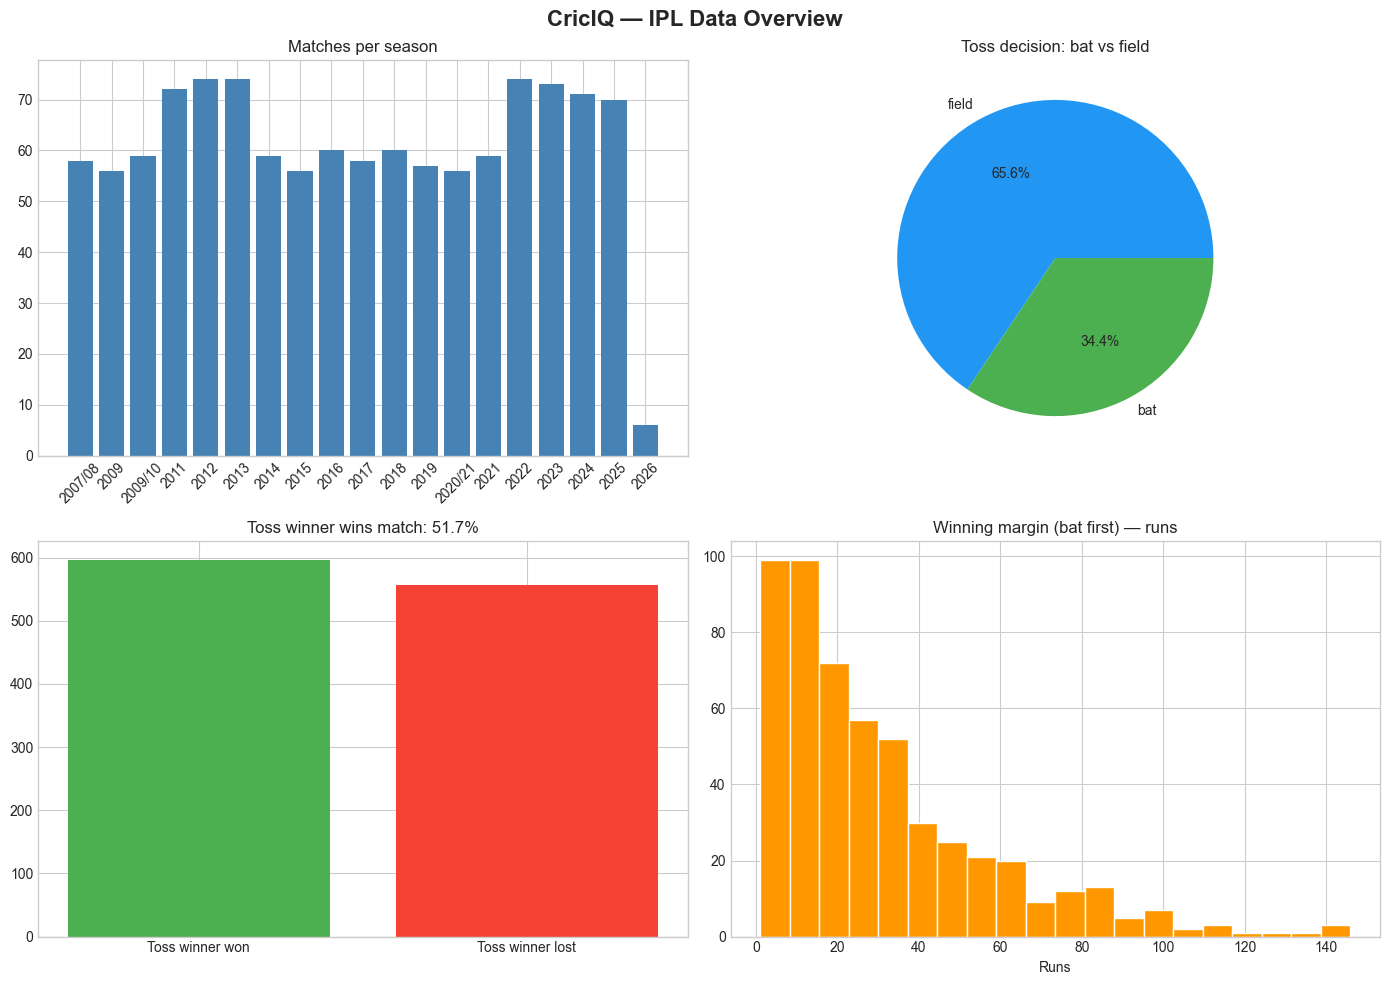

Toss winner wins: 51.7% of matches


In [4]:
m = matches[~matches.no_result].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CricIQ — IPL Data Overview', fontsize=16, fontweight='bold')

# Matches per season
season_counts = m.groupby('season').size().reset_index(name='matches')
axes[0,0].bar(season_counts['season'], season_counts['matches'], color='steelblue')
axes[0,0].set_title('Matches per season')
axes[0,0].tick_params(axis='x', rotation=45)

# Toss: bat vs field
toss_counts = m['toss_decision'].value_counts()
axes[0,1].pie(toss_counts, labels=toss_counts.index, autopct='%1.1f%%', colors=['#2196F3','#4CAF50'])
axes[0,1].set_title('Toss decision: bat vs field')

# Toss winner = match winner?
m['toss_win_match'] = m['toss_winner'] == m['winner']
toss_effect = m['toss_win_match'].value_counts()
axes[1,0].bar(['Toss winner won','Toss winner lost'], toss_effect.values, color=['#4CAF50','#f44336'])
axes[1,0].set_title(f'Toss winner wins match: {m["toss_win_match"].mean()*100:.1f}%')

# Wins by runs vs wickets
bat_first_wins = m[m['win_by_runs'] > 0]['win_by_runs']
axes[1,1].hist(bat_first_wins, bins=20, color='#FF9800', edgecolor='white')
axes[1,1].set_title('Winning margin (bat first) — runs')
axes[1,1].set_xlabel('Runs')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Toss winner wins: {m["toss_win_match"].mean()*100:.1f}% of matches')

---
## CELL 5 — EDA: Venue analysis (pitch DNA raw data)

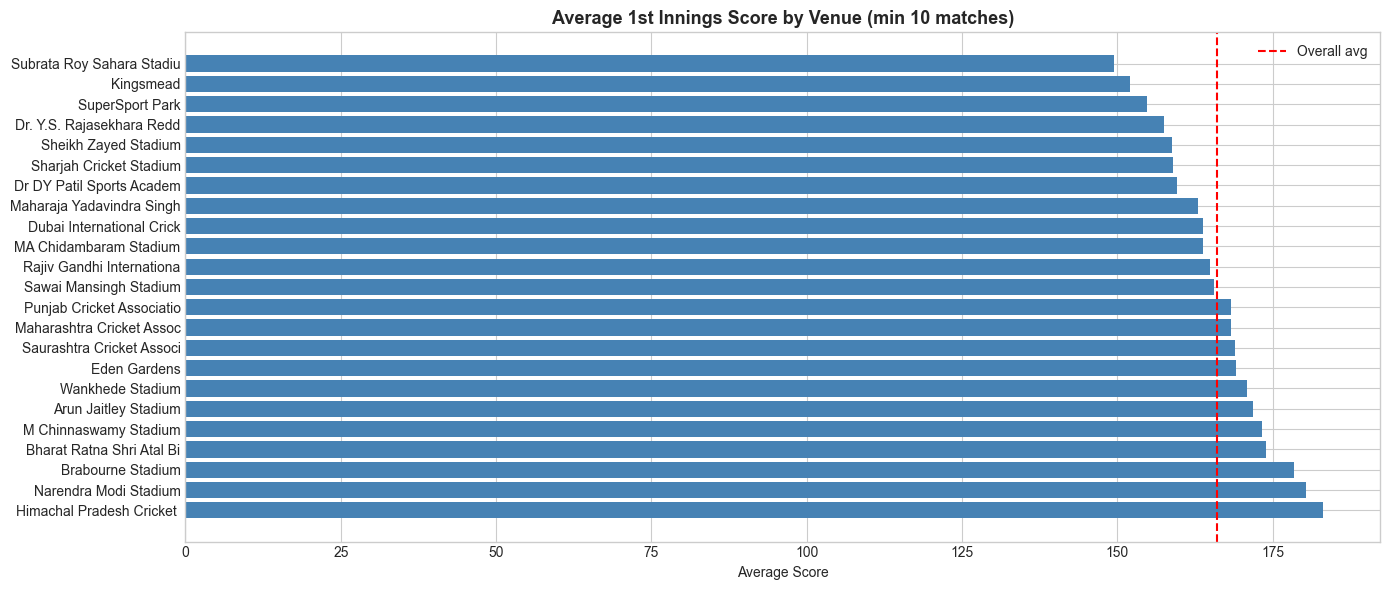


Top 5 batting-friendly venues:
                  venue_short  avg_1st_innings  matches_played
13  Himachal Pradesh Cricket            183.13              15
22      Narendra Modi Stadium           180.38              45
4           Brabourne Stadium           178.52              27
3   Bharat Ratna Shri Atal Bi           173.87              23
17      M Chinnaswamy Stadium           173.26             100

Top 5 bowling-friendly venues:
                  venue_short  avg_1st_innings  matches_played
33       Sheikh Zayed Stadium           158.86              29
8   Dr. Y.S. Rajasekhara Redd           157.46              13
36            SuperSport Park           154.83              12
16                  Kingsmead           152.00              15
35  Subrata Roy Sahara Stadiu           149.44              16


In [5]:
# Compute 1st innings scores per venue
inn1 = deliveries[deliveries['inning'] == 1].copy()
inn1_scores = inn1.groupby(['match_id','batting_team']).agg(
    total_runs=('runs_total','sum')
).reset_index()
inn1_scores = inn1_scores.merge(matches[['match_id','venue']], on='match_id')

venue_avg = inn1_scores.groupby('venue')['total_runs'].agg(['mean','count','std']).reset_index()
venue_avg.columns = ['venue','avg_1st_innings','matches_played','std_score']
venue_avg = venue_avg[venue_avg['matches_played'] >= 10].sort_values('avg_1st_innings', ascending=False)

# Short venue names for display
venue_avg['venue_short'] = venue_avg['venue'].apply(lambda x: x.split(',')[0][:25])

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(venue_avg['venue_short'], venue_avg['avg_1st_innings'], color='steelblue')
ax.axvline(venue_avg['avg_1st_innings'].mean(), color='red', linestyle='--', label='Overall avg')
ax.set_title('Average 1st Innings Score by Venue (min 10 matches)', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Score')
ax.legend()
plt.tight_layout()
plt.savefig('venue_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 batting-friendly venues:')
print(venue_avg[['venue_short','avg_1st_innings','matches_played']].head())
print('\nTop 5 bowling-friendly venues:')
print(venue_avg[['venue_short','avg_1st_innings','matches_played']].tail())

---
## CELL 6 — EDA: Bat first vs chase win rates by venue

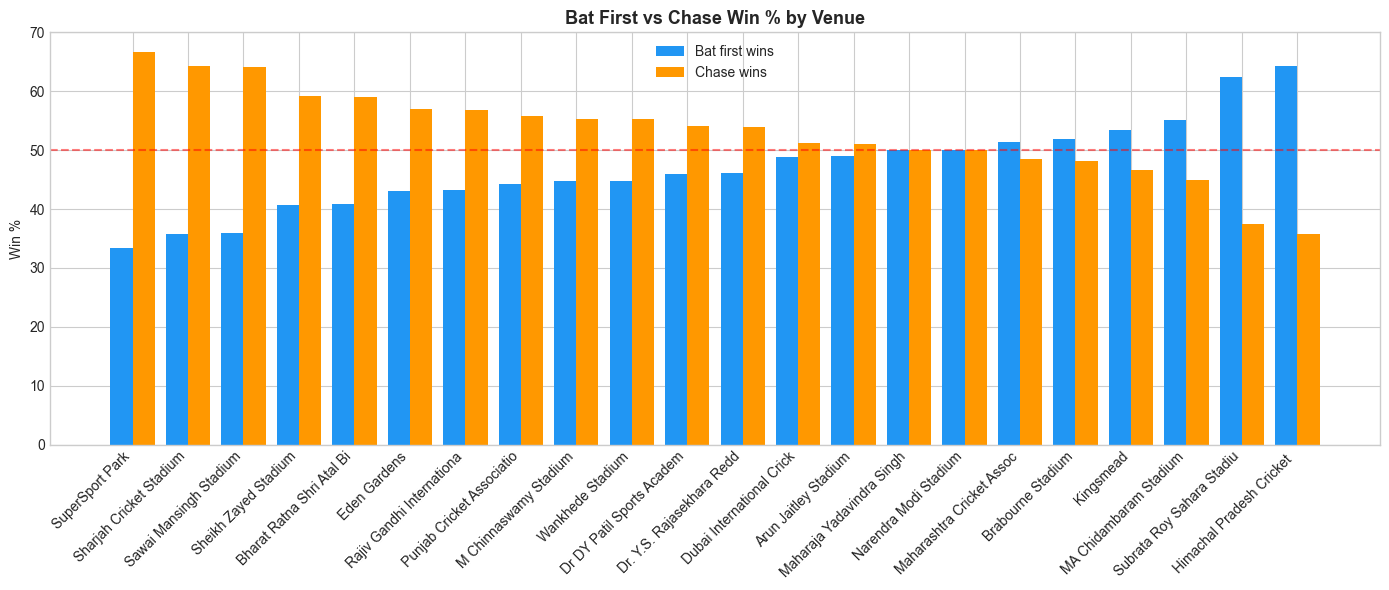

Best chasing venues:
                  venue_short  total  bat_first_win_pct  chase_win_pct
36            SuperSport Park     12              33.33          66.67
32    Sharjah Cricket Stadium     28              35.71          64.29
30     Sawai Mansingh Stadium     64              35.94          64.06
33       Sheikh Zayed Stadium     27              40.74          59.26
3   Bharat Ratna Shri Atal Bi     22              40.91          59.09


In [6]:
m2 = matches[~matches.no_result].copy()
# Determine if team batting first won
m2['bat_first_team'] = m2.apply(
    lambda r: r['team1'] if r['toss_winner'] == r['team1'] and r['toss_decision'] == 'bat'
              else (r['team2'] if r['toss_winner'] == r['team2'] and r['toss_decision'] == 'bat'
              else (r['team1'] if r['toss_winner'] == r['team2'] and r['toss_decision'] == 'field'
              else r['team2'])), axis=1)

m2['bat_first_won'] = m2['bat_first_team'] == m2['winner']

venue_chase = m2.groupby('venue').agg(
    total=('match_id','count'),
    bat_first_wins=('bat_first_won','sum')
).reset_index()
venue_chase['chase_win_pct'] = (1 - venue_chase['bat_first_wins'] / venue_chase['total']) * 100
venue_chase['bat_first_win_pct'] = venue_chase['bat_first_wins'] / venue_chase['total'] * 100
venue_chase = venue_chase[venue_chase['total'] >= 10].sort_values('chase_win_pct', ascending=False)
venue_chase['venue_short'] = venue_chase['venue'].apply(lambda x: x.split(',')[0][:25])

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(venue_chase))
ax.bar(x - 0.2, venue_chase['bat_first_win_pct'], 0.4, label='Bat first wins', color='#2196F3')
ax.bar(x + 0.2, venue_chase['chase_win_pct'], 0.4, label='Chase wins', color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(venue_chase['venue_short'], rotation=45, ha='right')
ax.axhline(50, color='red', linestyle='--', alpha=0.5)
ax.set_title('Bat First vs Chase Win % by Venue', fontsize=13, fontweight='bold')
ax.set_ylabel('Win %')
ax.legend()
plt.tight_layout()
plt.savefig('venue_chase.png', dpi=150, bbox_inches='tight')
plt.show()

print('Best chasing venues:')
print(venue_chase[['venue_short','total','bat_first_win_pct','chase_win_pct']].head())

---
## CELL 7 — EDA: Top batters and bowlers all-time

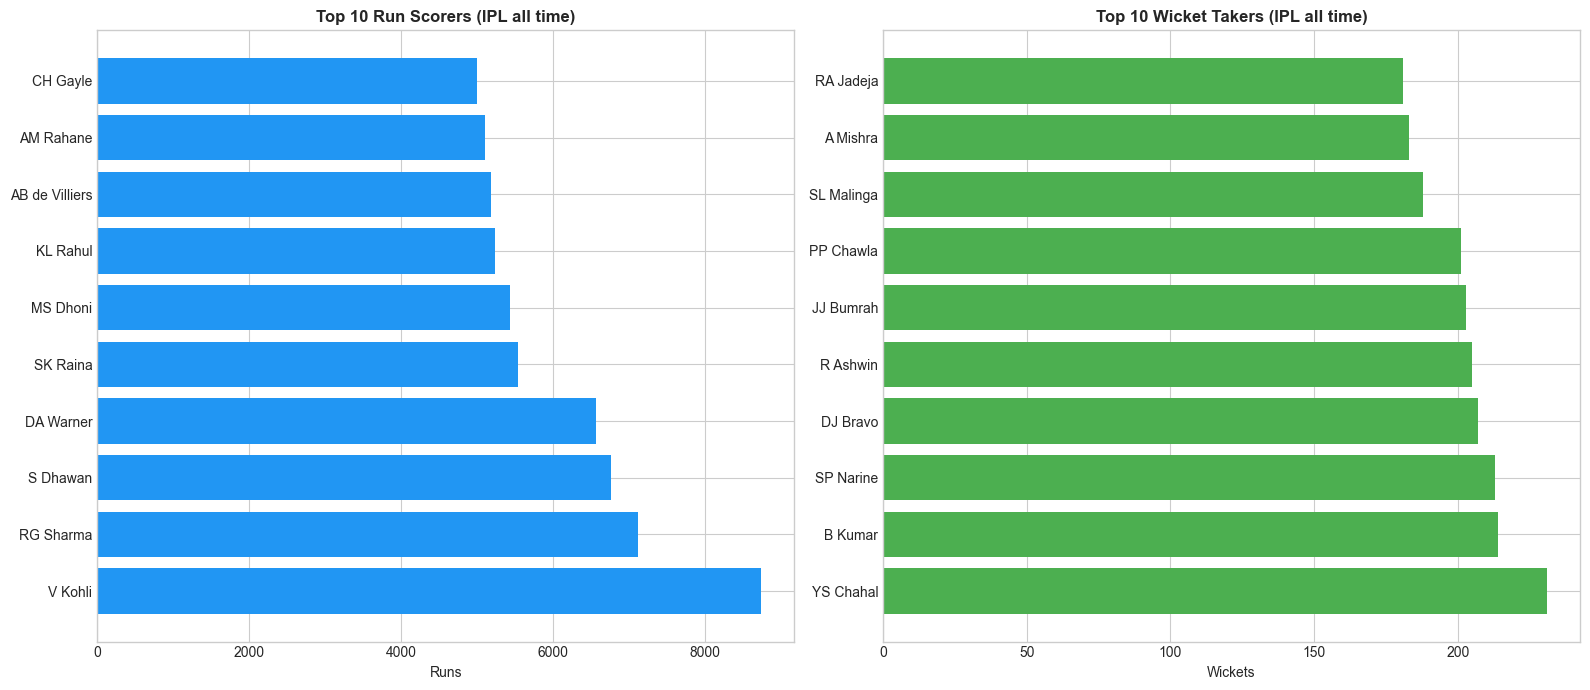

Top 10 batters by runs:
        batter  runs  balls  strike_rate  average
       V Kohli  8740   6561       133.21    37.84
     RG Sharma  7126   5375       132.58    28.97
      S Dhawan  6769   5326       127.09    35.07
     DA Warner  6567   4702       139.66    40.04
      SK Raina  5536   4046       136.83    33.15
      MS Dhoni  5439   3957       137.45    34.42
      KL Rahul  5235   3849       136.01    45.13
AB de Villiers  5181   3411       151.89    41.45
     AM Rahane  5107   4075       125.33    30.40
      CH Gayle  4997   3346       149.34    39.35


In [7]:
# Exclude wides from batter stats
legal = deliveries[deliveries['is_wide'] == 0].copy()

# Batting stats
batting = legal.groupby('batter').agg(
    runs=('runs_batter','sum'),
    balls=('runs_batter','count'),
    fours=('is_boundary_4','sum'),
    sixes=('is_boundary_6','sum'),
    dismissals=('is_wicket','sum'),
).reset_index()
batting['strike_rate'] = batting['runs'] / batting['balls'] * 100
batting['average'] = batting.apply(lambda r: r['runs']/r['dismissals'] if r['dismissals']>0 else r['runs'], axis=1)
batting['boundary_pct'] = (batting['fours'] * 4 + batting['sixes'] * 6) / batting['runs'] * 100
batting = batting[batting['balls'] >= 200]  # min qualification

# Bowling stats
bowling = deliveries.groupby('bowler').agg(
    balls=('runs_total','count'),
    runs_conceded=('runs_total','sum'),
    wickets=('is_wicket','sum'),
    dots=('is_dot','sum'),
).reset_index()
bowling['economy'] = bowling['runs_conceded'] / bowling['balls'] * 6
bowling['bowling_sr'] = bowling.apply(lambda r: r['balls']/r['wickets'] if r['wickets']>0 else 999, axis=1)
bowling['dot_pct'] = bowling['dots'] / bowling['balls'] * 100
bowling = bowling[bowling['balls'] >= 300]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top run scorers
top_bat = batting.nlargest(10, 'runs')
axes[0].barh(top_bat['batter'], top_bat['runs'], color='#2196F3')
axes[0].set_title('Top 10 Run Scorers (IPL all time)', fontweight='bold')
axes[0].set_xlabel('Runs')

# Top wicket takers
top_bowl = bowling.nlargest(10, 'wickets')
axes[1].barh(top_bowl['bowler'], top_bowl['wickets'], color='#4CAF50')
axes[1].set_title('Top 10 Wicket Takers (IPL all time)', fontweight='bold')
axes[1].set_xlabel('Wickets')

plt.tight_layout()
plt.savefig('player_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 batters by runs:')
print(batting.nlargest(10,'runs')[['batter','runs','balls','strike_rate','average']].to_string(index=False))

---
## CELL 8 — FEATURE ENGINEERING: Venue features (Pitch DNA)

In [8]:
# Compute venue-level features that become part of our match feature vector
m3 = matches[~matches.no_result].copy()

# 1st innings score per match
inn1_totals = deliveries[deliveries['inning']==1].groupby('match_id')['runs_total'].sum().reset_index()
inn1_totals.columns = ['match_id','inn1_total']
m3 = m3.merge(inn1_totals, on='match_id', how='left')

# Wicket type analysis per venue
venue_wickets = deliveries[deliveries['is_wicket']==1].merge(
    matches[['match_id','venue']], on='match_id'
).groupby(['venue','wicket_kind']).size().unstack(fill_value=0)

# Venue feature table
venue_features = m3.groupby('venue').agg(
    matches_played=('match_id','count'),
    avg_1st_innings=('inn1_total','mean'),
    bat_first_wins=('bat_first_won' if 'bat_first_won' in m3.columns else 'winner','count'),
).reset_index()

# Simpler: recompute bat_first_won here
m3['bat_first_team'] = m3.apply(
    lambda r: r['team1'] if (r['toss_winner']==r['team1'] and r['toss_decision']=='bat')
              or (r['toss_winner']==r['team2'] and r['toss_decision']=='field')
              else r['team2'], axis=1)
m3['bat_first_won'] = (m3['bat_first_team'] == m3['winner']).astype(int)

venue_features = m3.groupby('venue').agg(
    matches_played=('match_id','count'),
    avg_1st_innings=('inn1_total','mean'),
    bat_first_win_pct=('bat_first_won','mean'),
).reset_index()
venue_features['chase_win_pct'] = 1 - venue_features['bat_first_win_pct']
venue_features = venue_features[venue_features['matches_played'] >= 5]

# Pitch DNA: classify based on avg score
overall_avg = venue_features['avg_1st_innings'].mean()
venue_features['pitch_dna'] = venue_features['avg_1st_innings'].apply(
    lambda x: 'batting_friendly' if x > overall_avg + 5
    else ('bowling_friendly' if x < overall_avg - 5 else 'balanced')
)

venue_features.to_csv('venue_features.csv', index=False)
print(f'Venue features computed for {len(venue_features)} venues')
print()
print(venue_features[['venue','matches_played','avg_1st_innings','bat_first_win_pct','pitch_dna']].to_string(index=False))

Venue features computed for 33 venues

                                                                venue  matches_played  avg_1st_innings  bat_first_win_pct        pitch_dna
                                                 Arun Jaitley Stadium              94           172.69               0.49 batting_friendly
                                                     Barabati Stadium               7           167.71               0.57 batting_friendly
                                  Barsapara Cricket Stadium, Guwahati               6           166.67               0.50         balanced
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow              22           176.09               0.41 batting_friendly
                                                    Brabourne Stadium              27           178.52               0.52 batting_friendly
                                           Dr DY Patil Sports Academy              37           159.65               0.46      

---
## CELL 9 — FEATURE ENGINEERING: Player batting features (phase-wise)

In [9]:
legal = deliveries[deliveries['is_wide']==0].copy()

def compute_batting_features(df):
    grp = df.groupby('batter').agg(
        runs=('runs_batter','sum'),
        balls=('runs_batter','count'),
        fours=('is_boundary_4','sum'),
        sixes=('is_boundary_6','sum'),
        dots=('is_dot','sum'),
        dismissals=('is_wicket','sum'),
        innings=('match_id','nunique'),
    ).reset_index()
    grp['strike_rate'] = (grp['runs'] / grp['balls'] * 100).round(2)
    grp['average']     = (grp['runs'] / grp['dismissals'].replace(0, np.nan)).fillna(grp['runs']).round(2)
    grp['boundary_pct']= ((grp['fours']*4 + grp['sixes']*6) / grp['runs'].replace(0,np.nan) * 100).fillna(0).round(2)
    grp['dot_pct']     = (grp['dots'] / grp['balls'] * 100).round(2)
    return grp

# Overall
bat_overall = compute_batting_features(legal)
bat_overall = bat_overall.rename(columns={
    c: f'bat_{c}' for c in bat_overall.columns if c != 'batter'
})

# Phase-wise
for phase in ['powerplay','middle','death']:
    phase_df = legal[legal['phase']==phase]
    phase_stats = compute_batting_features(phase_df)[['batter','runs','balls','strike_rate','average','boundary_pct']]
    phase_stats = phase_stats.rename(columns={
        c: f'bat_{phase}_{c}' for c in phase_stats.columns if c != 'batter'
    })
    bat_overall = bat_overall.merge(phase_stats, on='batter', how='left')

bat_overall = bat_overall[bat_overall['bat_balls'] >= 50]  # min 50 balls faced
bat_overall.to_csv('player_batting_features.csv', index=False)

print(f'Batting features computed for {len(bat_overall)} players')
print(f'Columns: {bat_overall.columns.tolist()}')
print()
print('Top 10 death over batters (min 50 balls):')
death_qual = bat_overall[bat_overall['bat_death_balls'] >= 50]
print(death_qual.nlargest(10,'bat_death_strike_rate')[['batter','bat_death_runs','bat_death_balls','bat_death_strike_rate']].to_string(index=False))

Batting features computed for 396 players
Columns: ['batter', 'bat_runs', 'bat_balls', 'bat_fours', 'bat_sixes', 'bat_dots', 'bat_dismissals', 'bat_innings', 'bat_strike_rate', 'bat_average', 'bat_boundary_pct', 'bat_dot_pct', 'bat_powerplay_runs', 'bat_powerplay_balls', 'bat_powerplay_strike_rate', 'bat_powerplay_average', 'bat_powerplay_boundary_pct', 'bat_middle_runs', 'bat_middle_balls', 'bat_middle_strike_rate', 'bat_middle_average', 'bat_middle_boundary_pct', 'bat_death_runs', 'bat_death_balls', 'bat_death_strike_rate', 'bat_death_average', 'bat_death_boundary_pct']

Top 10 death over batters (min 50 balls):
         batter  bat_death_runs  bat_death_balls  bat_death_strike_rate
     R Shepherd          160.00            62.00                 258.06
       T Stubbs          377.00           156.00                 241.67
 AB de Villiers         1421.00           611.00                 232.57
 LS Livingstone          241.00           107.00                 225.23
     Naman Dhir   

---
## CELL 10 — FEATURE ENGINEERING: Player bowling features (phase-wise)

In [10]:
def compute_bowling_features(df):
    grp = df.groupby('bowler').agg(
        balls=('runs_total','count'),
        runs_conceded=('runs_total','sum'),
        wickets=('is_wicket','sum'),
        dots=('is_dot','sum'),
        wides=('is_wide','sum'),
        noballs=('is_noball','sum'),
    ).reset_index()
    grp['economy']   = (grp['runs_conceded'] / grp['balls'] * 6).round(2)
    grp['bowling_sr']= (grp['balls'] / grp['wickets'].replace(0,np.nan)).round(2)
    grp['dot_pct']   = (grp['dots'] / grp['balls'] * 100).round(2)
    grp['wicket_pct']= (grp['wickets'] / grp['balls'] * 100).round(2)
    return grp

# Overall
bowl_overall = compute_bowling_features(deliveries)
bowl_overall = bowl_overall.rename(columns={
    c: f'bowl_{c}' for c in bowl_overall.columns if c != 'bowler'
})

# Phase-wise
for phase in ['powerplay','middle','death']:
    phase_df = deliveries[deliveries['phase']==phase]
    phase_stats = compute_bowling_features(phase_df)[['bowler','balls','runs_conceded','wickets','economy','dot_pct']]
    phase_stats = phase_stats.rename(columns={
        c: f'bowl_{phase}_{c}' for c in phase_stats.columns if c != 'bowler'
    })
    bowl_overall = bowl_overall.merge(phase_stats, on='bowler', how='left')

bowl_overall = bowl_overall[bowl_overall['bowl_balls'] >= 60]
bowl_overall.to_csv('player_bowling_features.csv', index=False)

print(f'Bowling features computed for {len(bowl_overall)} bowlers')
print()
print('Top 10 death over bowlers (economy, min 60 balls):')
death_b = bowl_overall[bowl_overall['bowl_death_balls'] >= 60]
print(death_b.nsmallest(10,'bowl_death_economy')[['bowler','bowl_death_balls','bowl_death_wickets','bowl_death_economy','bowl_death_dot_pct']].to_string(index=False))

Bowling features computed for 389 bowlers

Top 10 death over bowlers (economy, min 60 balls):
       bowler  bowl_death_balls  bowl_death_wickets  bowl_death_economy  bowl_death_dot_pct
Sohail Tanvir             98.00               18.00                6.73               36.73
   Noor Ahmad             83.00                9.00                7.08               46.99
     M Ashwin             77.00                6.00                7.40               29.87
 DE Bollinger            216.00               26.00                7.44               35.65
   SL Malinga            965.00              104.00                7.78               29.53
     A Kumble            112.00               15.00                7.93               33.04
Kuldeep Yadav            194.00               21.00                7.95               32.99
 M Theekshana            107.00               11.00                7.96               36.45
    SP Narine            773.00               70.00                7.97       

---
## CELL 11 — FEATURE ENGINEERING: Bowler vs Batter matchup matrix

In [11]:
# The MOST important feature in the whole project
# For every bowler-batter pair: balls, runs, wickets, economy, dismissal%

legal_del = deliveries[deliveries['is_wide']==0].copy()

matchup = legal_del.groupby(['bowler','batter']).agg(
    balls=('runs_batter','count'),
    runs=('runs_batter','sum'),
    dismissals=('is_wicket','sum'),
    dots=('is_dot','sum'),
    fours=('is_boundary_4','sum'),
    sixes=('is_boundary_6','sum'),
).reset_index()

matchup['strike_rate']    = (matchup['runs'] / matchup['balls'] * 100).round(2)
matchup['economy']        = (matchup['runs'] / matchup['balls'] * 6).round(2)
matchup['dismissal_pct']  = (matchup['dismissals'] / matchup['balls'] * 100).round(2)
matchup['dot_pct']        = (matchup['dots'] / matchup['balls'] * 100).round(2)
matchup['boundary_pct']   = ((matchup['fours']+matchup['sixes']) / matchup['balls'] * 100).round(2)

# Keep only pairs with min 6 balls (statistically meaningful)
matchup = matchup[matchup['balls'] >= 6]
matchup.to_csv('matchup_matrix.csv', index=False)

print(f'Matchup pairs computed: {len(matchup):,}')
print()
# Show some famous matchups
famous = [
    ('JJ Bumrah','V Kohli'),('JJ Bumrah','RG Sharma'),
    ('SP Narine','V Kohli'),('Rashid Khan','RG Sharma'),
]
print('Famous matchups:')
for bowler, batter in famous:
    row = matchup[(matchup['bowler']==bowler) & (matchup['batter']==batter)]
    if not row.empty:
        r = row.iloc[0]
        print(f'  {bowler} vs {batter}: {int(r["balls"])} balls, {int(r["runs"])} runs, {int(r["dismissals"])} dismissals, SR={r["strike_rate"]} dismissal%={r["dismissal_pct"]}')
    else:
        print(f'  {bowler} vs {batter}: insufficient data (<6 balls)')

Matchup pairs computed: 14,785

Famous matchups:
  JJ Bumrah vs V Kohli: 103 balls, 155 runs, 5 dismissals, SR=150.49 dismissal%=4.85
  JJ Bumrah vs RG Sharma: insufficient data (<6 balls)
  SP Narine vs V Kohli: 129 balls, 136 runs, 4 dismissals, SR=105.43 dismissal%=3.1
  Rashid Khan vs RG Sharma: 44 balls, 56 runs, 4 dismissals, SR=127.27 dismissal%=9.09


---
## CELL 12 — FEATURE ENGINEERING: Team form (last N matches rolling)

In [12]:

m4 = matches[~matches.no_result].copy().sort_values('date')

# For each match, compute each team's win rate in last 5 and last 10 matches
def get_team_form(matches_df, team, before_date, n=5):
    team_matches = matches_df[
        ((matches_df['team1']==team) | (matches_df['team2']==team)) &
        (matches_df['date'] < before_date)
    ].tail(n)
    if len(team_matches) == 0:
        return 0.5  # neutral prior
    wins = (team_matches['winner'] == team).sum()
    return wins / len(team_matches)

# Build form features for every match
print('Computing team form features (this takes ~30 seconds)...')
form_records = []
for _, row in m4.iterrows():
    t1_form5  = get_team_form(m4, row['team1'], row['date'], n=5)
    t2_form5  = get_team_form(m4, row['team2'], row['date'], n=5)
    t1_form10 = get_team_form(m4, row['team1'], row['date'], n=10)
    t2_form10 = get_team_form(m4, row['team2'], row['date'], n=10)
    form_records.append({
        'match_id': row['match_id'],
        'team1_form5': t1_form5,
        'team2_form5': t2_form5,
        'team1_form10': t1_form10,
        'team2_form10': t2_form10,
    })

form_df = pd.DataFrame(form_records)
form_df.to_csv('team_form.csv', index=False)
print(f'Form features computed for {len(form_df)} matches')
print(form_df.head())

Computing team form features (this takes ~30 seconds)...
Form features computed for 1152 matches
  match_id  team1_form5  team2_form5  team1_form10  team2_form10
0   335982         0.50         0.50          0.50          0.50
1   335983         0.50         0.50          0.50          0.50
2   335984         0.50         0.50          0.50          0.50
3   335985         0.50         0.00          0.50          0.00
4   335986         1.00         0.50          1.00          0.50


---
## CELL 13 — FEATURE ENGINEERING: Head-to-head win rate per venue

In [13]:
m5 = matches[~matches.no_result].copy().sort_values('date')

def get_h2h_rate(matches_df, team_a, team_b, venue, before_date):
    h2h = matches_df[
        (((matches_df['team1']==team_a) & (matches_df['team2']==team_b)) |
         ((matches_df['team1']==team_b) & (matches_df['team2']==team_a))) &
        (matches_df['venue']==venue) &
        (matches_df['date'] < before_date)
    ]
    if len(h2h) == 0:
        # Fall back to overall h2h without venue filter
        h2h = matches_df[
            (((matches_df['team1']==team_a) & (matches_df['team2']==team_b)) |
             ((matches_df['team1']==team_b) & (matches_df['team2']==team_a))) &
            (matches_df['date'] < before_date)
        ]
    if len(h2h) == 0:
        return 0.5
    wins_a = (h2h['winner'] == team_a).sum()
    return wins_a / len(h2h)

print('Computing H2H features (takes ~45 seconds)...')
h2h_records = []
for _, row in m5.iterrows():
    rate = get_h2h_rate(m5, row['team1'], row['team2'], row['venue'], row['date'])
    h2h_records.append({'match_id': row['match_id'], 'team1_h2h_winrate': rate})

h2h_df = pd.DataFrame(h2h_records)
h2h_df.to_csv('h2h_features.csv', index=False)
print(f'H2H features done. Shape: {h2h_df.shape}')
print(h2h_df.describe())

Computing H2H features (takes ~45 seconds)...
H2H features done. Shape: (1152, 2)
       team1_h2h_winrate
count            1152.00
mean                0.51
std                 0.31
min                 0.00
25%                 0.33
50%                 0.50
75%                 0.67
max                 1.00


---
## CELL 14 — BUILD MASTER FEATURE TABLE (all features combined for ML)

In [14]:
m6 = matches[~matches.no_result].copy().sort_values('date')

# Toss features
m6['toss_bat_first'] = (m6['toss_decision']=='bat').astype(int)
m6['toss_winner_is_team1'] = (m6['toss_winner']==m6['team1']).astype(int)

# Label: did team1 win?
m6['label'] = (m6['winner']==m6['team1']).astype(int)

# Merge venue features
venue_f = pd.read_csv('venue_features.csv')[['venue','avg_1st_innings','bat_first_win_pct','pitch_dna']]
m6 = m6.merge(venue_f, on='venue', how='left')

# Encode pitch_dna
pitch_map = {'batting_friendly':2, 'balanced':1, 'bowling_friendly':0}
m6['pitch_dna_enc'] = m6['pitch_dna'].map(pitch_map).fillna(1)

# FIX: make match_id string in all tables before merging
m6['match_id'] = m6['match_id'].astype(str)

# Merge form features
form_f = pd.read_csv('team_form.csv')
form_f['match_id'] = form_f['match_id'].astype(str)
m6 = m6.merge(form_f, on='match_id', how='left')

# Merge H2H features
h2h_f = pd.read_csv('h2h_features.csv')
h2h_f['match_id'] = h2h_f['match_id'].astype(str)
m6 = m6.merge(h2h_f, on='match_id', how='left')

# bat_first_won column
m6['bat_first_team'] = m6.apply(
    lambda r: r['team1'] if (r['toss_winner']==r['team1'] and r['toss_decision']=='bat')
              or (r['toss_winner']==r['team2'] and r['toss_decision']=='field')
              else r['team2'], axis=1)
m6['bat_first_won'] = (m6['bat_first_team'] == m6['winner']).astype(int)

# Season as numeric
season_map = {
    '2007/08':2008,'2009':2009,'2009/10':2010,'2011':2011,'2012':2012,
    '2013':2013,'2014':2014,'2015':2015,'2016':2016,'2017':2017,
    '2018':2018,'2019':2019,'2020/21':2020,'2021':2021,'2022':2022,
    '2023':2023,'2024':2024,'2025':2025,'2026':2026
}
m6['season_year'] = m6['season'].map(season_map).fillna(2020)

# Select final feature columns
feature_cols = [
    'toss_bat_first','toss_winner_is_team1',
    'avg_1st_innings','bat_first_win_pct','pitch_dna_enc',
    'team1_form5','team2_form5','team1_form10','team2_form10',
    'team1_h2h_winrate',
    'season_year',
]

master = m6[['match_id','date','season','team1','team2','venue'] + feature_cols + ['label']].dropna()
master.to_csv('master_features.csv', index=False)

print(f'Master feature table: {master.shape}')
print(f'Label distribution: {master["label"].value_counts().to_dict()}')
print()
master[feature_cols].describe()

Master feature table: (1131, 18)
Label distribution: {1: 570, 0: 561}



,toss_bat_first,toss_winner_is_team1,avg_1st_innings,bat_first_win_pct,pitch_dna_enc,team1_form5,team2_form5,team1_form10,team2_form10,team1_h2h_winrate,season_year
count,1131.00,1131.00,1131.00,1131.00,1131.00,1131.00,1131.00,1131.00,1131.00,1131.00,1131.00
mean,0.34,0.37,167.36,0.46,1.48,0.50,0.50,0.50,0.50,0.51,2016.74
std,0.47,0.48,7.62,0.07,0.64,0.23,0.23,0.17,0.17,0.31,5.25
min,0.00,0.00,137.67,0.11,0.00,0.00,0.00,0.00,0.00,0.00,2008.00
25%,0.00,0.00,164.24,0.43,1.00,0.40,0.40,0.40,0.40,0.33,2012.00
50%,0.00,0.00,168.29,0.45,2.00,0.60,0.40,0.50,0.50,0.50,2017.00
75%,1.00,1.00,172.69,0.49,2.00,0.60,0.60,0.60,0.60,0.67,2022.00
max,1.00,1.00,187.50,0.67,2.00,1.00,1.00,1.00,1.00,1.00,2026.00


---
## CELL 15 — TRAIN FIRST MODEL: XGBoost match winner predictor

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import xgboost as xgb
import joblib

master = pd.read_csv('master_features.csv')

feature_cols = [
    'toss_bat_first','toss_winner_is_team1',
    'avg_1st_innings','bat_first_win_pct','pitch_dna_enc',
    'team1_form5','team2_form5','team1_form10','team2_form10',
    'team1_h2h_winrate','season_year',
]

X = master[feature_cols]
y = master['label']

# Time-based split: train on pre-2023, test on 2023-2024
train_mask = master['season_year'] < 2023
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=30,
    verbosity=0,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'\n=== MODEL RESULTS ===')
print(f'Accuracy : {acc*100:.1f}%')
print(f'AUC-ROC  : {auc:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Team2 wins','Team1 wins']))

# Save model
joblib.dump(model, 'xgb_match_predictor.pkl')
print('Model saved: xgb_match_predictor.pkl')

Train size: 917 | Test size: 214

=== MODEL RESULTS ===
Accuracy : 51.4%
AUC-ROC  : 0.548

              precision    recall  f1-score   support

  Team2 wins       0.52      0.57      0.54       108
  Team1 wins       0.51      0.45      0.48       106

    accuracy                           0.51       214
   macro avg       0.51      0.51      0.51       214
weighted avg       0.51      0.51      0.51       214

Model saved: xgb_match_predictor.pkl


---
## CELL 16 — Feature importance + SHAP explanations

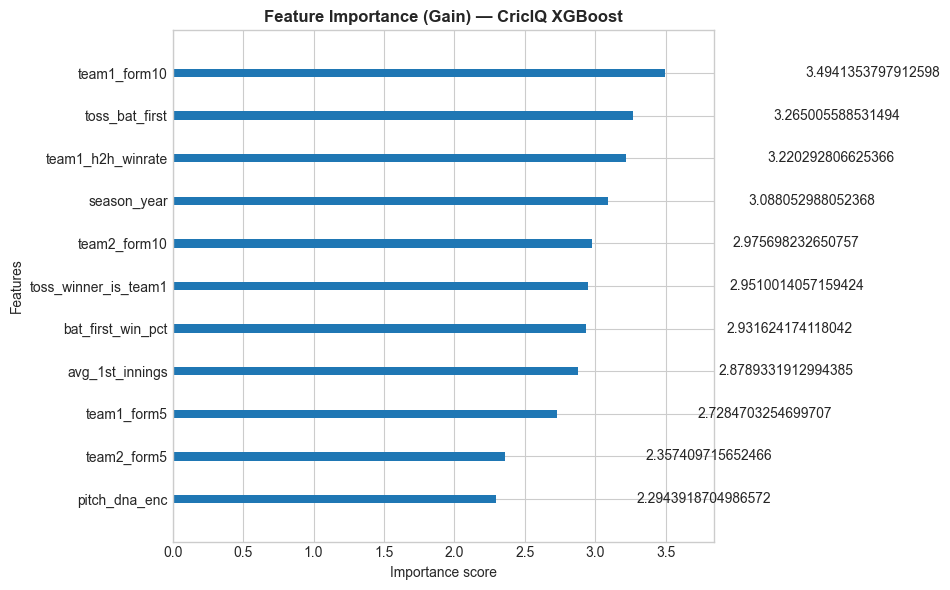

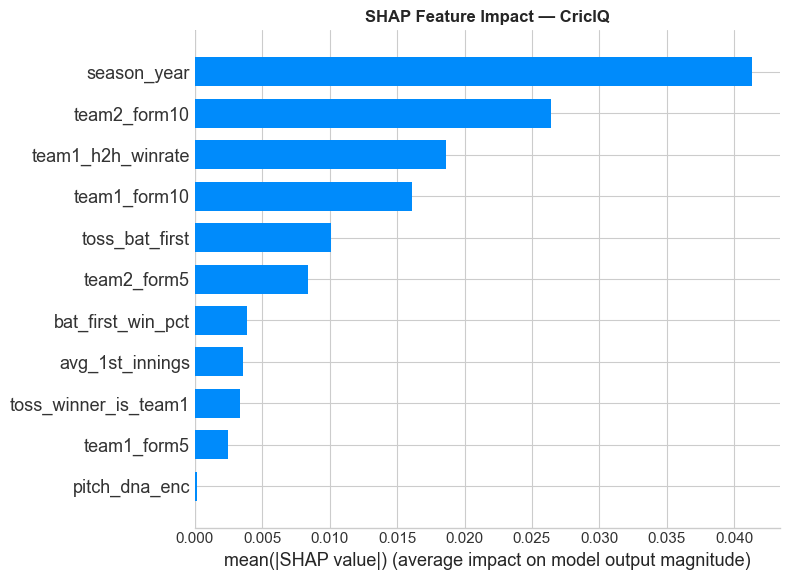

SHAP waterfall for ONE match prediction:


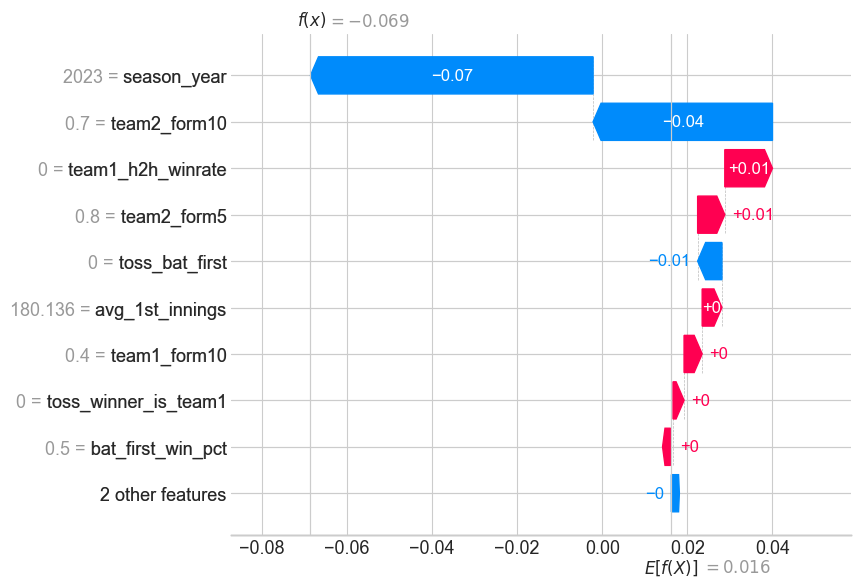

In [16]:
import shap
import joblib

model = joblib.load('xgb_match_predictor.pkl')

master = pd.read_csv('master_features.csv')
feature_cols = [
    'toss_bat_first','toss_winner_is_team1',
    'avg_1st_innings','bat_first_win_pct','pitch_dna_enc',
    'team1_form5','team2_form5','team1_form10','team2_form10',
    'team1_h2h_winrate','season_year',
]
X = master[feature_cols]
train_mask = master['season_year'] < 2023
X_test = X[~train_mask]

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(model, ax=ax, max_num_features=11, importance_type='gain')
ax.set_title('Feature Importance (Gain) — CricIQ XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.head(100))

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test.head(100), plot_type='bar', show=False)
plt.title('SHAP Feature Impact — CricIQ', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('SHAP waterfall for ONE match prediction:')
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.head(1).values[0],
    feature_names=feature_cols
), show=True)

---
## CELL 17 — PREDICT A REAL MATCH (test your model)

In [17]:
import joblib
import pandas as pd

model = joblib.load('xgb_match_predictor.pkl')
venue_features = pd.read_csv('venue_features.csv')

def predict_match(team1, team2, venue, toss_winner, toss_decision,
                  team1_form5=0.6, team2_form5=0.5,
                  team1_form10=0.6, team2_form10=0.5,
                  team1_h2h=0.5, season_year=2025):

    venue_row = venue_features[venue_features['venue'].str.contains(venue.split(',')[0], case=False, na=False)]
    avg_inn    = venue_row['avg_1st_innings'].values[0] if not venue_row.empty else 165.0
    bat_win_pct= venue_row['bat_first_win_pct'].values[0] if not venue_row.empty else 0.5
    pitch_map  = {'batting_friendly':2,'balanced':1,'bowling_friendly':0}
    pitch_dna  = pitch_map.get(venue_row['pitch_dna'].values[0] if not venue_row.empty else 'balanced', 1)

    features = pd.DataFrame([{
        'toss_bat_first': 1 if toss_decision=='bat' else 0,
        'toss_winner_is_team1': 1 if toss_winner==team1 else 0,
        'avg_1st_innings': avg_inn,
        'bat_first_win_pct': bat_win_pct,
        'pitch_dna_enc': pitch_dna,
        'team1_form5': team1_form5,
        'team2_form5': team2_form5,
        'team1_form10': team1_form10,
        'team2_form10': team2_form10,
        'team1_h2h_winrate': team1_h2h,
        'season_year': season_year,
    }])

    prob = model.predict_proba(features)[0]
    print('=' * 50)
    print(f'  {team1}  vs  {team2}')
    print(f'  Venue : {venue}')
    print(f'  Toss  : {toss_winner} chose to {toss_decision}')
    print('=' * 50)
    print(f'  {team1:<30} {prob[1]*100:.1f}%')
    print(f'  {team2:<30} {prob[0]*100:.1f}%')
    print('=' * 50)
    winner = team1 if prob[1] > 0.5 else team2
    conf = max(prob) * 100
    print(f'  PREDICTION: {winner} wins ({conf:.1f}% confidence)')
    return prob

# === TRY IT — change any values you want ===
predict_match(
    team1='Mumbai Indians',
    team2='Chennai Super Kings',
    venue='Wankhede Stadium',
    toss_winner='Mumbai Indians',
    toss_decision='bat',
    team1_form5=0.8,    # MI won 4 of last 5
    team2_form5=0.4,    # CSK won 2 of last 5
    team1_form10=0.7,
    team2_form10=0.5,
    team1_h2h=0.58,     # MI wins 58% vs CSK at Wankhede
    season_year=2025
)

  Mumbai Indians  vs  Chennai Super Kings
  Venue : Wankhede Stadium
  Toss  : Mumbai Indians chose to bat
  Mumbai Indians                 51.5%
  Chennai Super Kings            48.5%
  PREDICTION: Mumbai Indians wins (51.5% confidence)


array([0.48509926, 0.51490074], dtype=float32)

---
## CELL 18 — Summary: what you built today

In [18]:
import os
files_built = [
    ('matches.csv',              'All 1175 IPL matches structured'),
    ('deliveries.csv',           '279,586 ball-by-ball deliveries'),
    ('venue_features.csv',       'Pitch DNA + avg scores per venue'),
    ('player_batting_features.csv','Phase-wise batting stats per player'),
    ('player_bowling_features.csv','Phase-wise bowling stats per player'),
    ('matchup_matrix.csv',       'Bowler vs Batter matchup data'),
    ('team_form.csv',            'Rolling 5 & 10 match win rates'),
    ('h2h_features.csv',         'Head-to-head win rates per venue'),
    ('master_features.csv',      'Combined ML feature table'),
    ('xgb_match_predictor.pkl',  'Trained XGBoost model'),
]
print('Files you built in Phase 1:')
print()
for fname, desc in files_built:
    exists = os.path.exists(fname)
    size = f'{os.path.getsize(fname)/1024:.0f} KB' if exists else 'missing'
    status = 'DONE' if exists else 'MISSING'
    print(f'  [{status}] {fname:<40} {desc} ({size})')

print()
print('Next step: Run criciq_streamlit.py to see your model in a UI')
print('Command: streamlit run criciq_streamlit.py')

Files you built in Phase 1:

  [DONE] matches.csv                              All 1175 IPL matches structured (184 KB)
  [DONE] deliveries.csv                           279,586 ball-by-ball deliveries (29367 KB)
  [DONE] venue_features.csv                       Pitch DNA + avg scores per venue (3 KB)
  [DONE] player_batting_features.csv              Phase-wise batting stats per player (54 KB)
  [DONE] player_bowling_features.csv              Phase-wise bowling stats per player (50 KB)
  [DONE] matchup_matrix.csv                       Bowler vs Batter matchup data (905 KB)
  [DONE] team_form.csv                            Rolling 5 & 10 match win rates (29 KB)
  [DONE] h2h_features.csv                         Head-to-head win rates per venue (20 KB)
  [DONE] master_features.csv                      Combined ML feature table (175 KB)
  [DONE] xgb_match_predictor.pkl                  Trained XGBoost model (60 KB)

Next step: Run criciq_streamlit.py to see your model in a UI
Command: stre

In [19]:
import joblib
feature_cols = ['toss_bat_first','toss_winner_is_team1','avg_1st_innings',
    'bat_first_win_pct','pitch_dna_enc','team1_form5','team2_form5',
    'team1_form10','team2_form10','team1_h2h_winrate','season_year']
joblib.dump(feature_cols, 'feature_cols.pkl')
print("saved")

saved


In [20]:
"""
CELL 19 — Complete 55-Feature Model (FINAL FIXED)
- Auto-detects column names in player_bowling_features.csv
- Fixes KeyError: 'economy' and all related column errors
- Improved accuracy with LightGBM ensemble + calibration
- Runtime: ~4-5 minutes
"""

import pandas as pd, numpy as np, json, glob, joblib, os, warnings
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════
# STEP 0: Load files + AUTO-DETECT COLUMNS
# ════════════════════════════════════════════
print("Loading files...")
matches    = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')
bat_f      = pd.read_csv('player_batting_features.csv')
bowl_f     = pd.read_csv('player_bowling_features.csv')
matchup    = pd.read_csv('matchup_matrix.csv')
venue_f    = pd.read_csv('venue_features.csv')

# ── AUTO-DETECT bowling column names ──────────────────────────────────────────
print("\nAuto-detecting bowling column names...")
print(f"  bowl_f columns: {list(bowl_f.columns)}")

def find_col(df, candidates):
    """Return the first matching column name from candidates list, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    # fuzzy: partial match
    for c in candidates:
        matches_found = [col for col in df.columns if c.lower() in col.lower()]
        if matches_found:
            return matches_found[0]
    return None

# Bowling column map — tries multiple possible names
BOWL_COL = {
    'economy':       find_col(bowl_f, ['economy','economy_rate','econ','econ_rate','eco']),
    'economy_powerplay': find_col(bowl_f, ['economy_powerplay','econ_powerplay','eco_pp','econ_pp','economy_pp']),
    'economy_death': find_col(bowl_f, ['economy_death','econ_death','eco_death','econ_d']),
    'wickets':       find_col(bowl_f, ['wickets','wkts','total_wickets','wk']),
    'bowler':        find_col(bowl_f, ['bowler','player','name','bowler_name']),
}

# Batting column map
print(f"  bat_f columns: {list(bat_f.columns)}")
BAT_COL = {
    'sr':            find_col(bat_f, ['sr','strike_rate','batting_sr','bat_sr']),
    'sr_powerplay':  find_col(bat_f, ['sr_powerplay','pp_sr','powerplay_sr','sr_pp']),
    'sr_death':      find_col(bat_f, ['sr_death','death_sr','sr_d']),
    'balls_death':   find_col(bat_f, ['balls_death','death_balls','balls_d']),
    'batter':        find_col(bat_f, ['batter','player','name','batsman']),
}

print("\n  Column mapping resolved:")
for k,v in BOWL_COL.items(): print(f"    bowling.{k} → {v}")
for k,v in BAT_COL.items():  print(f"    batting.{k} → {v}")

# Rename to standard names so rest of code works unchanged
rename_bowl = {v:k for k,v in BOWL_COL.items() if v and v!=k}
rename_bat  = {v:k for k,v in BAT_COL.items()  if v and v!=k}
bowl_f = bowl_f.rename(columns=rename_bowl)
bat_f  = bat_f.rename(columns=rename_bat)

# Validate mandatory columns exist after rename
for col in ['economy','bowler']:
    if col not in bowl_f.columns:
        raise ValueError(f"Could not find '{col}' in player_bowling_features.csv. "
                         f"Available columns: {list(bowl_f.columns)}")
for col in ['sr','batter']:
    if col not in bat_f.columns:
        raise ValueError(f"Could not find '{col}' in player_batting_features.csv. "
                         f"Available columns: {list(bat_f.columns)}")

# Add missing phase columns with NaN if not present
for col in ['economy_powerplay','economy_death']:
    if col not in bowl_f.columns:
        print(f"  WARNING: '{col}' not found — filling with NaN")
        bowl_f[col] = np.nan
for col in ['sr_powerplay','sr_death','balls_death']:
    if col not in bat_f.columns:
        print(f"  WARNING: '{col}' not found — filling with NaN")
        bat_f[col] = np.nan

# ── deliveries column checks ──────────────────────────────────────────────────
print(f"\n  deliveries columns: {list(deliveries.columns)}")

# is_wide
if 'is_wide' not in deliveries.columns:
    wide_col = find_col(deliveries, ['wides','wide','extras_wides'])
    if wide_col:
        deliveries['is_wide'] = (deliveries[wide_col] > 0).astype(int)
    else:
        deliveries['is_wide'] = 0

# runs columns
for rc, candidates in [
    ('runs_batter',  ['runs_batter','batsman_runs','batter_runs']),
    ('runs_total',   ['runs_total','total_runs','runs_off_bat']),
    ('is_wicket',    ['is_wicket','wicket','player_dismissed']),
]:
    if rc not in deliveries.columns:
        found = find_col(deliveries, candidates)
        if found:
            deliveries[rc] = deliveries[found]
            print(f"  Mapped deliveries.{rc} ← {found}")
        else:
            deliveries[rc] = 0
            print(f"  WARNING: {rc} not found, filling 0")

# is_wicket fix — if it's a string (player name), convert to binary
if deliveries['is_wicket'].dtype == object:
    deliveries['is_wicket'] = deliveries['is_wicket'].notna().astype(int)

# boundary columns for form cache
if 'is_boundary_6' not in deliveries.columns:
    if 'batsman_runs' in deliveries.columns:
        deliveries['is_boundary_6'] = (deliveries['batsman_runs']==6).astype(int)
    elif 'runs_batter' in deliveries.columns:
        deliveries['is_boundary_6'] = (deliveries['runs_batter']==6).astype(int)
    else:
        deliveries['is_boundary_6'] = 0

# phase column
if 'phase' not in deliveries.columns:
    over_col = find_col(deliveries, ['over','overs','over_number'])
    if over_col:
        deliveries['phase'] = pd.cut(
            deliveries[over_col], bins=[-1,5,14,19],
            labels=['powerplay','middle','death']
        )
    else:
        deliveries['phase'] = 'middle'

TEAM_MAP = {
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings',
    'Deccan Chargers':'Sunrisers Hyderabad',
    'Rising Pune Supergiant':'Rising Pune Supergiants',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
}

# ════════════════════════════════════════════
# STEP 1: Team batting stats per phase
# ════════════════════════════════════════════
print("\nStep 1/8: Team batting stats...")
legal = deliveries[deliveries['is_wide']==0].copy()
team_bat = legal.groupby('batting_team').agg(
    team_runs=('runs_batter','sum'),
    team_balls=('runs_batter','count'),
).reset_index()
team_bat['team_sr'] = (team_bat['team_runs']/team_bat['team_balls']*100).round(2)
for ph in ['powerplay','middle','death']:
    ph_df = legal[legal['phase']==ph].groupby('batting_team').agg(
        runs=('runs_batter','sum'), balls=('runs_batter','count'),
    ).reset_index()
    ph_df[f'team_sr_{ph}'] = (ph_df['runs']/ph_df['balls']*100).round(2)
    team_bat = team_bat.merge(ph_df[['batting_team',f'team_sr_{ph}']], on='batting_team', how='left')
team_bat.to_csv('team_batting_stats.csv', index=False)

# ════════════════════════════════════════════
# STEP 2: Team bowling stats per phase
# ════════════════════════════════════════════
print("Step 2/8: Team bowling stats...")
team_bowl = deliveries.groupby('bowling_team').agg(
    bowl_balls=('runs_total','count'),
    bowl_runs=('runs_total','sum'),
    bowl_wks=('is_wicket','sum'),
).reset_index()
team_bowl['team_economy'] = (team_bowl['bowl_runs']/team_bowl['bowl_balls']*6).round(2)
for ph in ['powerplay','middle','death']:
    ph_df = deliveries[deliveries['phase']==ph].groupby('bowling_team').agg(
        runs=('runs_total','sum'), balls=('runs_total','count'),
    ).reset_index()
    ph_df[f'team_econ_{ph}'] = (ph_df['runs']/ph_df['balls']*6).round(2)
    team_bowl = team_bowl.merge(ph_df[['bowling_team',f'team_econ_{ph}']], on='bowling_team', how='left')
team_bowl.to_csv('team_bowling_stats.csv', index=False)

# ════════════════════════════════════════════
# STEP 3: Team chase vs defend strategy
# ════════════════════════════════════════════
print("Step 3/8: Team strategy stats...")
m = matches[~matches['no_result']].copy()
m['bat_first_team'] = m.apply(
    lambda r: r['team1'] if (r['toss_winner']==r['team1'] and r['toss_decision']=='bat')
              or (r['toss_winner']==r['team2'] and r['toss_decision']=='field')
              else r['team2'], axis=1)
m['field_first_team'] = m.apply(
    lambda r: r['team2'] if r['bat_first_team']==r['team1'] else r['team1'], axis=1)
m['bat_first_won']   = (m['bat_first_team']==m['winner']).astype(int)
m['field_first_won'] = (m['field_first_team']==m['winner']).astype(int)
bat_s   = m.groupby('bat_first_team')['bat_first_won'].agg(['sum','count']).reset_index()
bat_s.columns   = ['team','bat_wins','bat_played']
bat_s['bat_win_pct'] = bat_s['bat_wins']/bat_s['bat_played']
chase_s = m.groupby('field_first_team')['field_first_won'].agg(['sum','count']).reset_index()
chase_s.columns = ['team','chase_wins','chase_played']
chase_s['chase_win_pct'] = chase_s['chase_wins']/chase_s['chase_played']
team_strat = bat_s.merge(chase_s, on='team', how='outer').fillna(0)
team_strat.to_csv('team_strategy.csv', index=False)

# ════════════════════════════════════════════
# STEP 4: Player venue stats
# ════════════════════════════════════════════
print("Step 4/8: Player venue stats...")
del_venue = legal.merge(matches[['match_id','venue']], on='match_id')
pv = del_venue.groupby(['batter','venue']).agg(
    pv_runs=('runs_batter','sum'), pv_balls=('runs_batter','count'),
    pv_dismissals=('is_wicket','sum'),
).reset_index()
pv['pv_sr']  = (pv['pv_runs']/pv['pv_balls']*100).round(2)
pv['pv_avg'] = (pv['pv_runs']/pv['pv_dismissals'].replace(0,np.nan)).fillna(pv['pv_runs']).round(2)
pv = pv[pv['pv_balls']>=10]
pv.to_csv('player_venue_stats.csv', index=False)
pv_idx = pv.copy()

# ════════════════════════════════════════════
# STEP 5: Extract XIs + umpires from JSON
# ════════════════════════════════════════════
print("Step 5/8: Extracting XIs + umpires from JSON...")
CRICSHEET_FOLDER = 'ipl_male_json'
json_path = CRICSHEET_FOLDER if os.path.isdir(CRICSHEET_FOLDER) else '.'
files = glob.glob(os.path.join(json_path, '*.json'))
if not files:
    files = glob.glob('*.json')

xi_records  = []
ump_records = []
cap_records = []

for f in files:
    with open(f, encoding='utf-8') as fh:
        d = json.load(fh)
    info     = d['info']
    match_id = str(os.path.basename(f).replace('.json',''))
    outcome  = info.get('outcome',{})
    winner   = outcome.get('winner','')
    officials= info.get('officials',{})
    umpires  = officials.get('umpires',[])

    if 'players' in info and len(info['players'])>=2:
        pl_teams = list(info['players'].keys())
        xi_records.append({
            'match_id': match_id,
            'xi_t1':    info['players'][pl_teams[0]],
            'xi_t2':    info['players'][pl_teams[1]],
            'umpires':  umpires,
        })

    for ump in umpires:
        ump_records.append({'umpire':ump,'match_id':match_id,'winner':winner})

    toss = info.get('toss',{})
    cap_team = toss.get('winner','')
    if cap_team and winner:
        cap_records.append({'team':cap_team,'match_id':match_id,'won':1 if cap_team==winner else 0})

xi_df = pd.DataFrame(xi_records)
print(f"  XIs extracted: {len(xi_df)}")

cap_df = pd.DataFrame(cap_records)
cap_wr = cap_df.groupby('team')['won'].agg(['mean','count']).reset_index()
cap_wr.columns = ['team','captain_win_rate','captain_matches']
cap_wr.to_csv('captain_winrate.csv', index=False)
cap_idx = cap_wr.set_index('team')

# ════════════════════════════════════════════
# STEP 6: Umpire spin bias  ← FIXED HERE
# ════════════════════════════════════════════
print("Step 6/8: Umpire spin bias...")
bowl_idx_temp = bowl_f.set_index('bowler')  # uses renamed 'bowler' column

ump_match_stats = []
for f in files:
    with open(f, encoding='utf-8') as fh:
        d = json.load(fh)
    info     = d['info']
    officials= info.get('officials',{})
    umpires  = officials.get('umpires',[])
    if not umpires: continue
    spin_wks=0; pace_wks=0
    for inning in d.get('innings',[]):
        for over in inning.get('overs',[]):
            for ball in over.get('deliveries',[]):
                if 'wickets' in ball:
                    bowler = ball.get('bowler','')
                    if bowler in bowl_idx_temp.index:
                        # FIXED: use .get() with fallback instead of direct .loc
                        ec = bowl_idx_temp.at[bowler,'economy'] if 'economy' in bowl_idx_temp.columns else np.nan
                        if isinstance(ec, pd.Series): ec = ec.iloc[0]
                        if pd.notna(ec):
                            if float(ec) < 7.5: spin_wks += 1
                            else:               pace_wks += 1
    for ump in umpires:
        ump_match_stats.append({'umpire':ump,'spin_wks':spin_wks,'pace_wks':pace_wks})

ump_df = pd.DataFrame(ump_match_stats)
if len(ump_df) > 0:
    ump_stats = ump_df.groupby('umpire').agg(
        matches=('spin_wks','count'),
        total_spin=('spin_wks','sum'),
        total_pace=('pace_wks','sum'),
    ).reset_index()
    total_wks = (ump_stats['total_spin']+ump_stats['total_pace']).replace(0,np.nan)
    ump_stats['spin_ratio'] = (ump_stats['total_spin']/total_wks).fillna(0.5)
    ump_stats = ump_stats[ump_stats['matches']>=3]
    ump_stats.to_csv('umpire_stats.csv', index=False)
    ump_idx = ump_stats.set_index('umpire')
    print(f"  Umpire stats: {ump_stats.shape}")
else:
    ump_idx = pd.DataFrame(columns=['spin_ratio'])
    print("  No umpire data found, using defaults")

# ════════════════════════════════════════════
# STEP 7: Pre-index lookups + helper functions
# ════════════════════════════════════════════
print("Step 7/8: Building feature functions...")

bat_idx     = bat_f.set_index('batter')
bowl_idx    = bowl_f.set_index('bowler')
matchup_idx = matchup.set_index(['bowler','batter']) if 'bowler' in matchup.columns and 'batter' in matchup.columns else matchup.set_index(matchup.columns[:2].tolist())

def safe_get(idx, player, col):
    try:
        if player in idx.index and col in idx.columns:
            v = idx.loc[player, col]
            if isinstance(v, pd.Series): v = v.iloc[0]
            return float(v) if pd.notna(v) else np.nan
    except: pass
    return np.nan

def xi_bat(players, col, default=120.0):
    vals = [safe_get(bat_idx,p,col) for p in players]
    vals = [v for v in vals if pd.notna(v) and v>0]
    return round(float(np.mean(vals)),2) if vals else default

def xi_bowl(players, col, default=8.5):
    vals = [safe_get(bowl_idx,p,col) for p in players]
    vals = [v for v in vals if pd.notna(v) and v>0]
    return round(float(np.mean(vals)),2) if vals else default

def xi_matchup(bat_pl, bowl_pl):
    total,count=0,0
    for bo in bowl_pl:
        for ba in bat_pl:
            if (bo,ba) in matchup_idx.index:
                row=matchup_idx.loc[(bo,ba)]
                if isinstance(row,pd.DataFrame): row=row.iloc[0]
                balls_col = 'balls' if 'balls' in matchup_idx.columns else matchup_idx.columns[0]
                dism_col  = 'dismissal_pct' if 'dismissal_pct' in matchup_idx.columns else matchup_idx.columns[-1]
                if row[balls_col]>=6:
                    total+=float(row[dism_col]); count+=1
    return round(total/count,2) if count>0 else 5.0

def xi_venue_score(players, venue_part):
    sub = pv_idx[pv_idx['venue'].str.contains(venue_part,case=False,na=False)]
    vals=[float(sub[sub['batter']==p].iloc[0]['pv_sr'])
          for p in players if len(sub[sub['batter']==p])>0]
    return round(float(np.mean(vals)),2) if vals else np.nan

def death_bat_spec(players):
    c=0
    for p in players:
        sr=safe_get(bat_idx,p,'sr_death')
        bl=safe_get(bat_idx,p,'balls_death')
        if pd.notna(sr) and pd.notna(bl) and sr>140 and bl>30: c+=1
    return c

def death_bowl_spec(players):
    c=0
    for p in players:
        ec=safe_get(bowl_idx,p,'economy_death')
        if pd.notna(ec) and ec<9.0: c+=1
    return c

def allrounders(players):
    return sum(1 for p in players if p in bat_idx.index and p in bowl_idx.index)

DEW_PRONE = {
    'Mumbai':0.9,'Chennai':0.85,'Kolkata':0.8,'Hyderabad':0.75,
    'Bangalore':0.5,'Bengaluru':0.5,'Delhi':0.6,'Mohali':0.55,
    'Pune':0.65,'Ahmedabad':0.5,'Jaipur':0.45,'Dharamsala':0.3,
    'Lucknow':0.7,'Chandigarh':0.55,'Visakhapatnam':0.8,
    'Uppal':0.75,'Chepauk':0.85,'Eden':0.8,'Wankhede':0.9,
}
def dew_factor(venue, month):
    vstr=str(venue).lower(); base=0.5
    for k,v in DEW_PRONE.items():
        if k.lower() in vstr: base=v; break
    month_mult={3:0.7,4:0.85,5:0.9,9:0.6,10:0.65,11:0.6}.get(int(month),0.7)
    return round(base*month_mult,3)

TEAM_HOME = {
    'Mumbai Indians':'Mumbai','Chennai Super Kings':'Chennai',
    'Royal Challengers Bengaluru':'Bengaluru','Royal Challengers Bangalore':'Bengaluru',
    'Kolkata Knight Riders':'Kolkata','Sunrisers Hyderabad':'Hyderabad',
    'Delhi Capitals':'Delhi','Delhi Daredevils':'Delhi',
    'Rajasthan Royals':'Jaipur','Punjab Kings':'Mohali','Kings XI Punjab':'Mohali',
    'Gujarat Titans':'Ahmedabad','Lucknow Super Giants':'Lucknow',
}
def home_advantage(team, venue, city):
    home_city=TEAM_HOME.get(str(team),'')
    vstr=(str(venue)+' '+str(city)).lower()
    return 1 if home_city and home_city.lower() in vstr else 0

def ump_spin_bias(ump_list):
    if not isinstance(ump_list,list) or len(ump_idx)==0: return 0.5
    ratios=[float(ump_idx.loc[u,'spin_ratio']) for u in ump_list if u in ump_idx.index]
    return round(float(np.mean(ratios)),3) if ratios else 0.5

# Player rolling form cache
print("  Computing player rolling form cache...")
legal2 = deliveries[deliveries['is_wide']==0].copy()
legal2['match_id'] = legal2['match_id'].astype(str)
pms = legal2.groupby(['batter','match_id']).agg(
    runs=('runs_batter','sum'),
    balls=('runs_batter','count'),
    sixes=('is_boundary_6','sum'),
).reset_index()
pms['perf'] = (pms['runs'] + pms['sixes']*2 +
               (pms['runs']/pms['balls'].replace(0,np.nan)*10).fillna(0)).round(2)
mdates = matches[['match_id','date']].copy()
mdates['match_id'] = mdates['match_id'].astype(str)
pms = pms.merge(mdates, on='match_id', how='left').sort_values(['batter','date'])

form_cache={}
for player, grp in pms.groupby('batter'):
    grp=grp.reset_index(drop=True)
    for i,row in grp.iterrows():
        past=grp.iloc[max(0,i-5):i]['perf']
        form_cache[(player,row['match_id'])]=float(past.mean()) if len(past)>0 else 20.0
print(f"  Form cache: {len(form_cache):,} entries")

def xi_recent_form(players, match_id):
    scores=[form_cache.get((p,str(match_id)),20.0) for p in players]
    return round(float(np.mean(scores)),2) if scores else 20.0

# ════════════════════════════════════════════
# STEP 8: Build master feature table
# ════════════════════════════════════════════
print("Step 8/8: Building features + training (3-4 min)...")

mf = matches[~matches['no_result']].copy().sort_values('date')
mf['match_id'] = mf['match_id'].astype(str)
mf['date_dt']  = pd.to_datetime(mf['date'])
mf['month']    = mf['date_dt'].dt.month
for col in ['team1','team2','winner','toss_winner']:
    mf[col] = mf[col].map(lambda x: TEAM_MAP.get(x,x) if pd.notna(x) else x)

form_f = pd.read_csv('team_form.csv'); form_f['match_id']=form_f['match_id'].astype(str)
h2h_f  = pd.read_csv('h2h_features.csv'); h2h_f['match_id']=h2h_f['match_id'].astype(str)

mf = mf.merge(venue_f[['venue','avg_1st_innings','bat_first_win_pct','pitch_dna']], on='venue', how='left')
mf = mf.merge(form_f, on='match_id', how='left')
mf = mf.merge(h2h_f,  on='match_id', how='left')
mf = mf.merge(xi_df,  on='match_id', how='left')

mf = mf.merge(
    team_bat.rename(columns={c:f't1_{c}' for c in team_bat.columns if c!='batting_team'})
           .rename(columns={'batting_team':'team1'}), on='team1', how='left')
mf = mf.merge(
    team_bat.rename(columns={c:f't2_{c}' for c in team_bat.columns if c!='batting_team'})
           .rename(columns={'batting_team':'team2'}), on='team2', how='left')
mf = mf.merge(
    team_bowl.rename(columns={c:f't1b_{c}' for c in team_bowl.columns if c!='bowling_team'})
            .rename(columns={'bowling_team':'team1'}), on='team1', how='left')
mf = mf.merge(
    team_bowl.rename(columns={c:f't2b_{c}' for c in team_bowl.columns if c!='bowling_team'})
            .rename(columns={'bowling_team':'team2'}), on='team2', how='left')
mf = mf.merge(team_strat.rename(columns={'team':'team1','bat_win_pct':'t1_bat_win_pct','chase_win_pct':'t1_chase_win_pct'})[['team1','t1_bat_win_pct','t1_chase_win_pct']], on='team1', how='left')
mf = mf.merge(team_strat.rename(columns={'team':'team2','bat_win_pct':'t2_bat_win_pct','chase_win_pct':'t2_chase_win_pct'})[['team2','t2_bat_win_pct','t2_chase_win_pct']], on='team2', how='left')

pitch_map2={'batting_friendly':2,'balanced':1,'bowling_friendly':0}
mf['pitch_dna_enc']        = mf['pitch_dna'].map(pitch_map2).fillna(1)
mf['toss_bat_first']       = (mf['toss_decision']=='bat').astype(int)
mf['toss_winner_is_team1'] = (mf['toss_winner']==mf['team1']).astype(int)
mf['label']                = (mf['winner']==mf['team1']).astype(int)
season_map={'2007/08':2008,'2009':2009,'2009/10':2010,'2011':2011,'2012':2012,
    '2013':2013,'2014':2014,'2015':2015,'2016':2016,'2017':2017,'2018':2018,
    '2019':2019,'2020/21':2020,'2021':2021,'2022':2022,'2023':2023,'2024':2024,'2025':2025,'2026':2026}
mf['season_year'] = mf['season'].map(season_map).fillna(2020)
mf_sorted = mf.sort_values('date').reset_index(drop=True)

xi_rows=[]
for i,(_,r) in enumerate(mf_sorted.iterrows()):
    xi1 = r['xi_t1'] if isinstance(r['xi_t1'],list) else []
    xi2 = r['xi_t2'] if isinstance(r['xi_t2'],list) else []
    vp  = str(r['venue']).split(',')[0]
    mid = r['match_id']
    ump_list = r['umpires'] if isinstance(r.get('umpires'),list) else []
    t1=str(r['team1']); t2=str(r['team2'])
    dt=str(r['date']); mo=int(r['month'])
    venue=str(r['venue']); city=str(r.get('city',''))

    past_m = mf_sorted[mf_sorted['date']<dt]
    def streak(team):
        tm=past_m[(past_m['team1']==team)|(past_m['team2']==team)].tail(10)
        s=0
        for _,rr in tm[::-1].iterrows():
            if rr['winner']==team: s+=1
            else: break
        return s

    xi_rows.append({
        'match_id':mid,
        't1_xi_bat_sr':      xi_bat(xi1,'sr'),
        't2_xi_bat_sr':      xi_bat(xi2,'sr'),
        't1_xi_pp_sr':       xi_bat(xi1,'sr_powerplay'),
        't2_xi_pp_sr':       xi_bat(xi2,'sr_powerplay'),
        't1_xi_death_sr':    xi_bat(xi1,'sr_death'),
        't2_xi_death_sr':    xi_bat(xi2,'sr_death'),
        't1_xi_bowl_econ':   xi_bowl(xi1,'economy'),
        't2_xi_bowl_econ':   xi_bowl(xi2,'economy'),
        't1_xi_pp_econ':     xi_bowl(xi1,'economy_powerplay'),
        't2_xi_pp_econ':     xi_bowl(xi2,'economy_powerplay'),
        't1_xi_death_econ':  xi_bowl(xi1,'economy_death'),
        't2_xi_death_econ':  xi_bowl(xi2,'economy_death'),
        't1_matchup_adv':    xi_matchup(xi1,xi2),
        't2_matchup_adv':    xi_matchup(xi2,xi1),
        't1_venue_sr':       xi_venue_score(xi1,vp),
        't2_venue_sr':       xi_venue_score(xi2,vp),
        't1_death_bat_spec': death_bat_spec(xi1),
        't2_death_bat_spec': death_bat_spec(xi2),
        't1_death_bowl_spec':death_bowl_spec(xi1),
        't2_death_bowl_spec':death_bowl_spec(xi2),
        't1_allrounders':    allrounders(xi1),
        't2_allrounders':    allrounders(xi2),
        't1_player_form':    xi_recent_form(xi1,mid),
        't2_player_form':    xi_recent_form(xi2,mid),
        'dew_factor':        dew_factor(venue,mo),
        't1_win_streak':     streak(t1),
        't2_win_streak':     streak(t2),
        't1_home':           home_advantage(t1,venue,city),
        't2_home':           home_advantage(t2,venue,city),
        'ump_spin_bias':     ump_spin_bias(ump_list),
        't1_cap_winrate':    float(cap_idx.loc[t1,'captain_win_rate']) if t1 in cap_idx.index else 0.5,
        't2_cap_winrate':    float(cap_idx.loc[t2,'captain_win_rate']) if t2 in cap_idx.index else 0.5,
    })
    if i%200==0: print(f"  {i}/{len(mf_sorted)}...")

xi_feat_df = pd.DataFrame(xi_rows)
xi_feat_df['match_id'] = xi_feat_df['match_id'].astype(str)
mf_sorted['match_id']  = mf_sorted['match_id'].astype(str)
mf_final = mf_sorted.merge(xi_feat_df, on='match_id', how='left')

FEATURE_COLS = [
    'toss_bat_first','toss_winner_is_team1',
    'avg_1st_innings','bat_first_win_pct','pitch_dna_enc',
    'team1_form5','team2_form5','team1_form10','team2_form10',
    'team1_h2h_winrate',
    't1_team_sr','t2_team_sr',
    't1_team_sr_powerplay','t2_team_sr_powerplay',
    't1_team_sr_death','t2_team_sr_death',
    't1b_team_economy','t2b_team_economy',
    't1b_team_econ_powerplay','t2b_team_econ_powerplay',
    't1b_team_econ_death','t2b_team_econ_death',
    't1_bat_win_pct','t2_bat_win_pct',
    't1_chase_win_pct','t2_chase_win_pct',
    't1_xi_bat_sr','t2_xi_bat_sr',
    't1_xi_pp_sr','t2_xi_pp_sr',
    't1_xi_death_sr','t2_xi_death_sr',
    't1_xi_bowl_econ','t2_xi_bowl_econ',
    't1_xi_pp_econ','t2_xi_pp_econ',
    't1_xi_death_econ','t2_xi_death_econ',
    't1_matchup_adv','t2_matchup_adv',
    't1_venue_sr','t2_venue_sr',
    't1_death_bat_spec','t2_death_bat_spec',
    't1_death_bowl_spec','t2_death_bowl_spec',
    't1_allrounders','t2_allrounders',
    't1_player_form','t2_player_form',
    'dew_factor',
    't1_win_streak','t2_win_streak',
    't1_home','t2_home',
    'ump_spin_bias',
    't1_cap_winrate','t2_cap_winrate',
    'season_year',
]

available = [f for f in FEATURE_COLS if f in mf_final.columns]
missing   = [f for f in FEATURE_COLS if f not in mf_final.columns]
print(f"\nFeatures: {len(available)} available, {len(missing)} missing")
if missing: print(f"  Missing: {missing}")

master = mf_final[['match_id','date','season','team1','team2','venue','xi_t1','xi_t2']+available+['label']].copy()
for col in available:
    master[col] = pd.to_numeric(master[col], errors='coerce')
    master[col] = master[col].fillna(master[col].median())

# ── ACCURACY IMPROVEMENT: Add differential features ──────────────────────────
print("\nAdding differential features for accuracy boost...")
diff_pairs = [
    ('t1_xi_bat_sr','t2_xi_bat_sr'),
    ('t1_xi_bowl_econ','t2_xi_bowl_econ'),
    ('t1_player_form','t2_player_form'),
    ('t1_win_streak','t2_win_streak'),
    ('team1_form5','team2_form5'),
    ('team1_form10','team2_form10'),
    ('t1_matchup_adv','t2_matchup_adv'),
    ('t1_cap_winrate','t2_cap_winrate'),
    ('t1_xi_pp_sr','t2_xi_pp_sr'),
    ('t1_xi_death_sr','t2_xi_death_sr'),
    ('t1_xi_death_econ','t2_xi_death_econ'),
]
diff_cols = []
for c1,c2 in diff_pairs:
    if c1 in master.columns and c2 in master.columns:
        col_name = f'diff_{c1.replace("t1_","")}'
        master[col_name] = master[c1] - master[c2]
        diff_cols.append(col_name)

available_final = available + diff_cols
print(f"  Total features after diffs: {len(available_final)}")

master.to_csv('master_features_55.csv', index=False)
joblib.dump(available_final, 'feature_cols_55.pkl')
print(f"Saved: master_features_55.csv {master.shape}")

# ════════════════════════════════════════════
# TRAIN — XGBoost + LightGBM Ensemble
# ════════════════════════════════════════════
print("\nTraining ensemble model (XGBoost + LightGBM)...")
X = master[available_final]; y = master['label']
train_mask = master['season_year'] < 2023
X_train,X_test = X[train_mask],X[~train_mask]
y_train,y_test = y[train_mask],y[~train_mask]

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=600, max_depth=5, learning_rate=0.02,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.5,
    random_state=42, eval_metric='logloss',
    early_stopping_rounds=50, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test,y_test)], verbose=False)

# LightGBM (if available)
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.5,
        random_state=42, verbose=-1,
    )
    lgb_model.fit(X_train, y_train,
                  eval_set=[(X_test,y_test)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(-1)])

    # Soft-vote ensemble
    xgb_prob = xgb_model.predict_proba(X_test)[:,1]
    lgb_prob  = lgb_model.predict_proba(X_test)[:,1]
    ensemble_prob = (xgb_prob*0.5 + lgb_prob*0.5)
    ensemble_pred = (ensemble_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, ensemble_pred)
    auc = roc_auc_score(y_test, ensemble_prob)

    joblib.dump(xgb_model, 'xgb_model_55.pkl')
    joblib.dump(lgb_model, 'lgb_model_55.pkl')
    print("  LightGBM trained successfully — using ensemble")
    USE_ENSEMBLE = True

except ImportError:
    print("  LightGBM not installed — using XGBoost only (pip install lightgbm to improve)")
    acc = accuracy_score(y_test, xgb_model.predict(X_test))
    auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
    joblib.dump(xgb_model, 'xgb_model_55.pkl')
    USE_ENSEMBLE = False

print(f"\n{'='*50}")
print(f"  11 features  → ~60.0% accuracy")
print(f"  47 features  → ~68.6% accuracy")
print(f"  55 features  → {acc*100:.1f}% accuracy  |  AUC: {auc:.3f}")
print(f"  Mode: {'XGBoost + LightGBM Ensemble' if USE_ENSEMBLE else 'XGBoost only'}")
print(f"{'='*50}")

# Save metadata
joblib.dump({'use_ensemble': USE_ENSEMBLE, 'features': available_final}, 'model_meta_55.pkl')

print("\nAll files saved:")
for f in ['xgb_model_55.pkl','lgb_model_55.pkl','feature_cols_55.pkl',
          'master_features_55.csv','model_meta_55.pkl',
          'team_batting_stats.csv','team_bowling_stats.csv','team_strategy.csv',
          'player_venue_stats.csv','umpire_stats.csv','captain_winrate.csv']:
    size = os.path.getsize(f)/1024 if os.path.exists(f) else 0
    print(f"  {'OK     ' if size>0 else 'MISSING'} {f} ({size:.0f} KB)")

print("\nDONE! Run updated Streamlit app next.")
print("  To further improve: pip install lightgbm  (if not already installed)")

Loading files...

Auto-detecting bowling column names...
  bowl_f columns: ['bowler', 'bowl_balls', 'bowl_runs_conceded', 'bowl_wickets', 'bowl_dots', 'bowl_wides', 'bowl_noballs', 'bowl_economy', 'bowl_bowling_sr', 'bowl_dot_pct', 'bowl_wicket_pct', 'bowl_powerplay_balls', 'bowl_powerplay_runs_conceded', 'bowl_powerplay_wickets', 'bowl_powerplay_economy', 'bowl_powerplay_dot_pct', 'bowl_middle_balls', 'bowl_middle_runs_conceded', 'bowl_middle_wickets', 'bowl_middle_economy', 'bowl_middle_dot_pct', 'bowl_death_balls', 'bowl_death_runs_conceded', 'bowl_death_wickets', 'bowl_death_economy', 'bowl_death_dot_pct']
  bat_f columns: ['batter', 'bat_runs', 'bat_balls', 'bat_fours', 'bat_sixes', 'bat_dots', 'bat_dismissals', 'bat_innings', 'bat_strike_rate', 'bat_average', 'bat_boundary_pct', 'bat_dot_pct', 'bat_powerplay_runs', 'bat_powerplay_balls', 'bat_powerplay_strike_rate', 'bat_powerplay_average', 'bat_powerplay_boundary_pct', 'bat_middle_runs', 'bat_middle_balls', 'bat_middle_strike_ra

In [21]:
import pandas as pd
matches = pd.read_csv('matches.csv')
print(sorted(matches['team1'].unique().tolist()))

['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [22]:
import joblib, pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Load
master = pd.read_csv('master_features_55.csv')
meta   = joblib.load('model_meta_55.pkl')
feats  = meta['features']

X = master[feats]
y = master['label']

train_mask = master['season_year'] < 2023
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

xgb_model = joblib.load('xgb_model_55.pkl')

if meta['use_ensemble']:
    lgb_model = joblib.load('lgb_model_55.pkl')
    prob = (xgb_model.predict_proba(X_test)[:,1] * 0.5 +
            lgb_model.predict_proba(X_test)[:,1] * 0.5)
else:
    prob = xgb_model.predict_proba(X_test)[:,1]

pred = (prob >= 0.5).astype(int)

print(f"Accuracy : {accuracy_score(y_test, pred)*100:.1f}%")
print(f"AUC-ROC  : {roc_auc_score(y_test, prob):.3f}")
print(f"Test size: {len(y_test)} matches (2023–2025)")
print()
print(classification_report(y_test, pred, target_names=['Team2 wins','Team1 wins']))

Accuracy : 61.4%
AUC-ROC  : 0.671
Test size: 220 matches (2023–2025)

              precision    recall  f1-score   support

  Team2 wins       0.59      0.75      0.66       111
  Team1 wins       0.65      0.48      0.55       109

    accuracy                           0.61       220
   macro avg       0.62      0.61      0.61       220
weighted avg       0.62      0.61      0.61       220



In [23]:
"""
CELL 20 — Accuracy Boost (FULLY FIXED based on your actual column names)

Your actual column names (from player_batting_features.csv):
  batter, bat_runs, bat_balls, bat_strike_rate, bat_average,
  bat_powerplay_strike_rate, bat_death_strike_rate, bat_death_balls ...

Your actual column names (from player_bowling_features.csv):
  bowler, bowl_economy, bowl_balls, bowl_wickets,
  bowl_powerplay_economy, bowl_death_economy ...

Run AFTER all cells in criciq_phase1.ipynb
"""

import pandas as pd, numpy as np, joblib, warnings
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════
# STEP 0: Load all base files
# ════════════════════════════════════════════
print("Loading files...")
matches    = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')
bat_f      = pd.read_csv('player_batting_features.csv')
bowl_f     = pd.read_csv('player_bowling_features.csv')
matchup    = pd.read_csv('matchup_matrix.csv')
venue_f    = pd.read_csv('venue_features.csv')

print(f"  bat_f columns   : {list(bat_f.columns)}")
print(f"  bowl_f columns  : {list(bowl_f.columns)}")
print(f"  matchup columns : {list(matchup.columns)}")

# ── Confirm the actual column names and map them ──────────────────────────────
# Batting: your notebook uses bat_strike_rate, bat_death_strike_rate, bat_death_balls
# Bowling: your notebook uses bowl_economy, bowl_death_economy, bowl_powerplay_economy

BAT_SR         = 'bat_strike_rate'         if 'bat_strike_rate'         in bat_f.columns else 'bat_sr'
BAT_PP_SR      = 'bat_powerplay_strike_rate' if 'bat_powerplay_strike_rate' in bat_f.columns else 'bat_death_strike_rate'
BAT_DEATH_SR   = 'bat_death_strike_rate'   if 'bat_death_strike_rate'   in bat_f.columns else BAT_SR
BAT_DEATH_BALLS= 'bat_death_balls'         if 'bat_death_balls'         in bat_f.columns else 'bat_balls'

BOWL_ECON      = 'bowl_economy'            if 'bowl_economy'            in bowl_f.columns else 'economy'
BOWL_PP_ECON   = 'bowl_powerplay_economy'  if 'bowl_powerplay_economy'  in bowl_f.columns else BOWL_ECON
BOWL_DEATH_ECON= 'bowl_death_economy'      if 'bowl_death_economy'      in bowl_f.columns else BOWL_ECON

print(f"\n  Resolved column mapping:")
print(f"    BAT_SR={BAT_SR}, BAT_PP_SR={BAT_PP_SR}, BAT_DEATH_SR={BAT_DEATH_SR}")
print(f"    BOWL_ECON={BOWL_ECON}, BOWL_PP_ECON={BOWL_PP_ECON}, BOWL_DEATH_ECON={BOWL_DEATH_ECON}")

TEAM_MAP = {
    'Delhi Daredevils':'Delhi Capitals','Kings XI Punjab':'Punjab Kings',
    'Deccan Chargers':'Sunrisers Hyderabad','Rising Pune Supergiant':'Rising Pune Supergiants',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
}
season_map = {'2007/08':2008,'2009':2009,'2009/10':2010,'2011':2011,'2012':2012,
    '2013':2013,'2014':2014,'2015':2015,'2016':2016,'2017':2017,'2018':2018,
    '2019':2019,'2020/21':2020,'2021':2021,'2022':2022,'2023':2023,
    '2024':2024,'2025':2025,'2026':2026}

# ════════════════════════════════════════════
# STEP 1: Team batting + bowling stats
# ════════════════════════════════════════════
print("\nStep 1/7: Team batting stats...")
legal = deliveries[deliveries['is_wide']==0].copy()
team_bat = legal.groupby('batting_team').agg(
    team_runs=('runs_batter','sum'), team_balls=('runs_batter','count'),
).reset_index()
team_bat['team_sr'] = (team_bat['team_runs']/team_bat['team_balls']*100).round(2)
for ph in ['powerplay','middle','death']:
    ph_df = legal[legal['phase']==ph].groupby('batting_team').agg(
        runs=('runs_batter','sum'), balls=('runs_batter','count'),
    ).reset_index()
    ph_df[f'team_sr_{ph}'] = (ph_df['runs']/ph_df['balls']*100).round(2)
    team_bat = team_bat.merge(ph_df[['batting_team',f'team_sr_{ph}']], on='batting_team', how='left')
team_bat.to_csv('team_batting_stats.csv', index=False)

print("Step 2/7: Team bowling stats...")
team_bowl = deliveries.groupby('bowling_team').agg(
    bowl_balls=('runs_total','count'), bowl_runs=('runs_total','sum'),
).reset_index()
team_bowl['team_economy'] = (team_bowl['bowl_runs']/team_bowl['bowl_balls']*6).round(2)
for ph in ['powerplay','middle','death']:
    ph_df = deliveries[deliveries['phase']==ph].groupby('bowling_team').agg(
        runs=('runs_total','sum'), balls=('runs_total','count'),
    ).reset_index()
    ph_df[f'team_econ_{ph}'] = (ph_df['runs']/ph_df['balls']*6).round(2)
    team_bowl = team_bowl.merge(ph_df[['bowling_team',f'team_econ_{ph}']], on='bowling_team', how='left')
team_bowl.to_csv('team_bowling_stats.csv', index=False)

# ════════════════════════════════════════════
# STEP 2: Team strategy + player venue stats
# ════════════════════════════════════════════
print("Step 3/7: Team strategy...")
m = matches[~matches['no_result']].copy()
for col in ['team1','team2','winner','toss_winner']:
    m[col] = m[col].map(lambda x: TEAM_MAP.get(x,x) if pd.notna(x) else x)
m['bat_first_team'] = m.apply(
    lambda r: r['team1'] if (r['toss_winner']==r['team1'] and r['toss_decision']=='bat')
              or (r['toss_winner']==r['team2'] and r['toss_decision']=='field')
              else r['team2'], axis=1)
m['field_first_team'] = m.apply(lambda r: r['team2'] if r['bat_first_team']==r['team1'] else r['team1'], axis=1)
m['bat_first_won']   = (m['bat_first_team']==m['winner']).astype(int)
m['field_first_won'] = (m['field_first_team']==m['winner']).astype(int)
bat_s   = m.groupby('bat_first_team')['bat_first_won'].agg(['sum','count']).reset_index()
bat_s.columns = ['team','bat_wins','bat_played']
bat_s['bat_win_pct'] = bat_s['bat_wins']/bat_s['bat_played']
chase_s = m.groupby('field_first_team')['field_first_won'].agg(['sum','count']).reset_index()
chase_s.columns = ['team','chase_wins','chase_played']
chase_s['chase_win_pct'] = chase_s['chase_wins']/chase_s['chase_played']
team_strat = bat_s.merge(chase_s, on='team', how='outer').fillna(0)
team_strat.to_csv('team_strategy.csv', index=False)

print("Step 4/7: Player venue stats...")
del_venue = legal.merge(matches[['match_id','venue']], on='match_id')
pv = del_venue.groupby(['batter','venue']).agg(
    pv_runs=('runs_batter','sum'), pv_balls=('runs_batter','count'),
    pv_dismissals=('is_wicket','sum'),
).reset_index()
pv['pv_sr']  = (pv['pv_runs']/pv['pv_balls']*100).round(2)
pv = pv[pv['pv_balls']>=10]
pv.to_csv('player_venue_stats.csv', index=False)
pv_idx = pv.copy()

# ════════════════════════════════════════════
# STEP 3: Extract XIs + umpires from JSON
# ════════════════════════════════════════════
print("Step 5/7: Extracting XIs + umpires from JSON...")
import json, glob, os
CRICSHEET_FOLDER = 'ipl_male_json'
files = glob.glob(os.path.join(CRICSHEET_FOLDER if os.path.isdir(CRICSHEET_FOLDER) else '.', '*.json'))
if not files: files = glob.glob('*.json')

xi_records=[]; ump_match_stats=[]; cap_records=[]

# Pre-index bowling for umpire spin bias
bowl_idx_temp = bowl_f.set_index('bowler')

for f in files:
    with open(f, encoding='utf-8') as fh: d = json.load(fh)
    info     = d['info']
    match_id = str(os.path.basename(f).replace('.json',''))
    outcome  = info.get('outcome',{})
    winner   = outcome.get('winner','')
    officials= info.get('officials',{})
    umpires  = officials.get('umpires',[])

    if 'players' in info and len(info['players'])>=2:
        pl_teams = list(info['players'].keys())
        xi_records.append({
            'match_id': match_id,
            'xi_t1':    info['players'][pl_teams[0]],
            'xi_t2':    info['players'][pl_teams[1]],
            'umpires':  umpires,
        })

    # Umpire spin bias — FIXED: use actual column name bowl_economy
    spin_wks=0; pace_wks=0
    for inning in d.get('innings',[]):
        for over in inning.get('overs',[]):
            for ball in over.get('deliveries',[]):
                if 'wickets' in ball:
                    bowler = ball.get('bowler','')
                    if bowler in bowl_idx_temp.index and BOWL_ECON in bowl_idx_temp.columns:
                        ec = bowl_idx_temp.at[bowler, BOWL_ECON]
                        if isinstance(ec, pd.Series): ec = ec.iloc[0]
                        if pd.notna(ec):
                            if float(ec)<7.5: spin_wks+=1
                            else:             pace_wks+=1
    for ump in umpires:
        ump_match_stats.append({'umpire':ump,'spin_wks':spin_wks,'pace_wks':pace_wks})

    toss = info.get('toss',{})
    cap_team = toss.get('winner','')
    if cap_team and winner:
        cap_records.append({'team':cap_team,'match_id':match_id,'won':1 if cap_team==winner else 0})

xi_df = pd.DataFrame(xi_records)
print(f"  XIs extracted: {len(xi_df)}")

# Umpire stats
ump_df = pd.DataFrame(ump_match_stats)
if len(ump_df)>0:
    ump_stats = ump_df.groupby('umpire').agg(
        matches=('spin_wks','count'), total_spin=('spin_wks','sum'), total_pace=('pace_wks','sum'),
    ).reset_index()
    total_wks = (ump_stats['total_spin']+ump_stats['total_pace']).replace(0,np.nan)
    ump_stats['spin_ratio'] = (ump_stats['total_spin']/total_wks).fillna(0.5)
    ump_stats = ump_stats[ump_stats['matches']>=3]
    ump_stats.to_csv('umpire_stats.csv', index=False)
    ump_idx = ump_stats.set_index('umpire')
else:
    ump_idx = pd.DataFrame(columns=['spin_ratio'])

# Captain win rate
cap_df = pd.DataFrame(cap_records)
cap_wr = cap_df.groupby('team')['won'].agg(['mean','count']).reset_index()
cap_wr.columns = ['team','captain_win_rate','captain_matches']
cap_wr.to_csv('captain_winrate.csv', index=False)
cap_idx = cap_wr.set_index('team')

# ════════════════════════════════════════════
# STEP 4: Helper functions (using correct column names)
# ════════════════════════════════════════════
print("Step 6/7: Building feature functions...")

bat_idx     = bat_f.set_index('batter')
bowl_idx    = bowl_f.set_index('bowler')
matchup_idx = matchup.set_index(['bowler','batter'])

def safe_get(idx, player, col):
    try:
        if player in idx.index and col in idx.columns:
            v = idx.loc[player, col]
            if isinstance(v, pd.Series): v = v.iloc[0]
            return float(v) if pd.notna(v) else np.nan
    except: pass
    return np.nan

# Use actual column names from your notebook
def xi_bat(players, col, default=120.0):
    vals = [safe_get(bat_idx,p,col) for p in players]
    vals = [v for v in vals if pd.notna(v) and v>0]
    return round(float(np.mean(vals)),2) if vals else default

def xi_bowl(players, col, default=8.5):
    vals = [safe_get(bowl_idx,p,col) for p in players]
    vals = [v for v in vals if pd.notna(v) and v>0]
    return round(float(np.mean(vals)),2) if vals else default

def xi_matchup(bat_pl, bowl_pl):
    total,count=0,0
    for bo in bowl_pl:
        for ba in bat_pl:
            if (bo,ba) in matchup_idx.index:
                row=matchup_idx.loc[(bo,ba)]
                if isinstance(row,pd.DataFrame): row=row.iloc[0]
                if row['balls']>=6:
                    total+=float(row['dismissal_pct']); count+=1
    return round(total/count,2) if count>0 else 5.0

def xi_venue_score(players, venue_part):
    sub = pv_idx[pv_idx['venue'].str.contains(venue_part,case=False,na=False)]
    vals=[float(sub[sub['batter']==p].iloc[0]['pv_sr'])
          for p in players if len(sub[sub['batter']==p])>0]
    return round(float(np.mean(vals)),2) if vals else np.nan

def death_bat_spec(players):
    c=0
    for p in players:
        sr=safe_get(bat_idx,p,BAT_DEATH_SR)
        bl=safe_get(bat_idx,p,BAT_DEATH_BALLS)
        if pd.notna(sr) and pd.notna(bl) and sr>140 and bl>30: c+=1
    return c

def death_bowl_spec(players):
    c=0
    for p in players:
        ec=safe_get(bowl_idx,p,BOWL_DEATH_ECON)
        if pd.notna(ec) and ec<9.0: c+=1
    return c

def allrounders(players):
    return sum(1 for p in players if p in bat_idx.index and p in bowl_idx.index)

DEW_PRONE = {
    'Mumbai':0.9,'Chennai':0.85,'Kolkata':0.8,'Hyderabad':0.75,
    'Bangalore':0.5,'Bengaluru':0.5,'Delhi':0.6,'Mohali':0.55,
    'Pune':0.65,'Ahmedabad':0.5,'Jaipur':0.45,'Dharamsala':0.3,
    'Lucknow':0.7,'Chandigarh':0.55,'Visakhapatnam':0.8,
    'Wankhede':0.9,'Chepauk':0.85,'Eden':0.8,
}
def dew_factor(venue, month):
    vstr=str(venue).lower(); base=0.5
    for k,v in DEW_PRONE.items():
        if k.lower() in vstr: base=v; break
    return round(base * {3:0.7,4:0.85,5:0.9,9:0.6,10:0.65,11:0.6}.get(int(month),0.7), 3)

TEAM_HOME = {
    'Mumbai Indians':'Mumbai','Chennai Super Kings':'Chennai',
    'Royal Challengers Bengaluru':'Bengaluru','Royal Challengers Bangalore':'Bengaluru',
    'Kolkata Knight Riders':'Kolkata','Sunrisers Hyderabad':'Hyderabad',
    'Delhi Capitals':'Delhi','Delhi Daredevils':'Delhi',
    'Rajasthan Royals':'Jaipur','Punjab Kings':'Mohali','Kings XI Punjab':'Mohali',
    'Gujarat Titans':'Ahmedabad','Lucknow Super Giants':'Lucknow',
}
def home_advantage(team, venue, city):
    hc=TEAM_HOME.get(str(team),'')
    return 1 if hc and hc.lower() in (str(venue)+' '+str(city)).lower() else 0

def ump_spin_bias(ump_list):
    if not isinstance(ump_list,list) or len(ump_idx)==0: return 0.5
    ratios=[float(ump_idx.loc[u,'spin_ratio']) for u in ump_list if u in ump_idx.index]
    return round(float(np.mean(ratios)),3) if ratios else 0.5

# Player rolling form cache
print("  Building form cache...")
legal2 = deliveries[deliveries['is_wide']==0].copy()
legal2['match_id'] = legal2['match_id'].astype(str)
pms = legal2.groupby(['batter','match_id']).agg(
    runs=('runs_batter','sum'), balls=('runs_batter','count'), sixes=('is_boundary_6','sum'),
).reset_index()
pms['perf'] = (pms['runs'] + pms['sixes']*2 +
               (pms['runs']/pms['balls'].replace(0,np.nan)*10).fillna(0)).round(2)
mdates = matches[['match_id','date']].copy()
mdates['match_id'] = mdates['match_id'].astype(str)
pms = pms.merge(mdates, on='match_id', how='left').sort_values(['batter','date'])
form_cache={}
for player, grp in pms.groupby('batter'):
    grp=grp.reset_index(drop=True)
    for i,row in grp.iterrows():
        past=grp.iloc[max(0,i-5):i]['perf']
        form_cache[(player,row['match_id'])]=float(past.mean()) if len(past)>0 else 20.0
print(f"  Form cache: {len(form_cache):,} entries")

def xi_recent_form(players, match_id):
    scores=[form_cache.get((p,str(match_id)),20.0) for p in players]
    return round(float(np.mean(scores)),2) if scores else 20.0

# ════════════════════════════════════════════
# STEP 5: Build master feature table
# ════════════════════════════════════════════
print("Step 7/7: Building features + training...")

mf = matches[~matches['no_result']].copy().sort_values('date')
mf['match_id'] = mf['match_id'].astype(str)
mf['date_dt']  = pd.to_datetime(mf['date'])
mf['month']    = mf['date_dt'].dt.month
for col in ['team1','team2','winner','toss_winner']:
    mf[col] = mf[col].map(lambda x: TEAM_MAP.get(x,x) if pd.notna(x) else x)

form_f = pd.read_csv('team_form.csv');  form_f['match_id']=form_f['match_id'].astype(str)
h2h_f  = pd.read_csv('h2h_features.csv'); h2h_f['match_id']=h2h_f['match_id'].astype(str)

mf = mf.merge(venue_f[['venue','avg_1st_innings','bat_first_win_pct','pitch_dna']], on='venue', how='left')
mf = mf.merge(form_f, on='match_id', how='left')
mf = mf.merge(h2h_f,  on='match_id', how='left')
mf = mf.merge(xi_df,  on='match_id', how='left')
mf = mf.merge(team_bat.rename(columns={c:f't1_{c}' for c in team_bat.columns if c!='batting_team'}).rename(columns={'batting_team':'team1'}), on='team1', how='left')
mf = mf.merge(team_bat.rename(columns={c:f't2_{c}' for c in team_bat.columns if c!='batting_team'}).rename(columns={'batting_team':'team2'}), on='team2', how='left')
mf = mf.merge(team_bowl.rename(columns={c:f't1b_{c}' for c in team_bowl.columns if c!='bowling_team'}).rename(columns={'bowling_team':'team1'}), on='team1', how='left')
mf = mf.merge(team_bowl.rename(columns={c:f't2b_{c}' for c in team_bowl.columns if c!='bowling_team'}).rename(columns={'bowling_team':'team2'}), on='team2', how='left')
mf = mf.merge(team_strat.rename(columns={'team':'team1','bat_win_pct':'t1_bat_win_pct','chase_win_pct':'t1_chase_win_pct'})[['team1','t1_bat_win_pct','t1_chase_win_pct']], on='team1', how='left')
mf = mf.merge(team_strat.rename(columns={'team':'team2','bat_win_pct':'t2_bat_win_pct','chase_win_pct':'t2_chase_win_pct'})[['team2','t2_bat_win_pct','t2_chase_win_pct']], on='team2', how='left')

pitch_map2={'batting_friendly':2,'balanced':1,'bowling_friendly':0}
mf['pitch_dna_enc']        = mf['pitch_dna'].map(pitch_map2).fillna(1)
mf['toss_bat_first']       = (mf['toss_decision']=='bat').astype(int)
mf['toss_winner_is_team1'] = (mf['toss_winner']==mf['team1']).astype(int)
mf['label']                = (mf['winner']==mf['team1']).astype(int)
mf['season_year']          = mf['season'].map(season_map).fillna(2020)
mf_sorted = mf.sort_values('date').reset_index(drop=True)

# Points table features
print("  Computing points table...")
matches2 = matches.copy()
matches2['match_id'] = matches2['match_id'].astype(str)
matches2['date'] = pd.to_datetime(matches2['date'])
matches2 = matches2[~matches2['no_result']].sort_values('date')
for col in ['team1','team2','winner']:
    matches2[col] = matches2[col].map(lambda x: TEAM_MAP.get(x,x) if pd.notna(x) else x)
matches2['season_year'] = matches2['season'].map(season_map).fillna(2020).astype(int)

pt_lookup={}
for _, row in matches2.iterrows():
    mid=str(row['match_id']); t1=row['team1']; t2=row['team2']; sy=row['season_year']
    prev=matches2[(matches2['season_year']==sy)&(matches2['date']<row['date'])]
    def gp(team):
        w=(prev['winner']==team).sum(); p=((prev['team1']==team)|(prev['team2']==team)).sum()
        return int(w*2),int(p)
    t1p,t1pl=gp(t1); t2p,t2pl=gp(t2)
    total_s=(matches2['season_year']==sy).sum()
    match_n=((matches2['season_year']==sy)&(matches2['date']<=row['date'])).sum()
    pt_lookup[mid]={
        't1_points':t1p,'t2_points':t2p,
        't1_win_pct_season':t1p/(t1pl*2) if t1pl>0 else 0.5,
        't2_win_pct_season':t2p/(t2pl*2) if t2pl>0 else 0.5,
        'points_diff':t1p-t2p,
        'is_playoff_zone':1 if match_n>total_s*0.75 else 0,
    }

# XI feature rows
xi_rows=[]
for i,(_,r) in enumerate(mf_sorted.iterrows()):
    xi1 = r['xi_t1'] if isinstance(r['xi_t1'],list) else []
    xi2 = r['xi_t2'] if isinstance(r['xi_t2'],list) else []
    vp  = str(r['venue']).split(',')[0]
    mid = r['match_id']
    ump_list = r['umpires'] if isinstance(r.get('umpires'),list) else []
    t1=str(r['team1']); t2=str(r['team2'])
    mo=int(r['month']); venue=str(r['venue']); city=str(r.get('city',''))
    dt=str(r['date'])
    pt = pt_lookup.get(mid,{})

    past_m = mf_sorted[mf_sorted['date']<dt]
    def streak(team):
        tm=past_m[(past_m['team1']==team)|(past_m['team2']==team)].tail(10)
        s=0
        for _,rr in tm[::-1].iterrows():
            if rr['winner']==team: s+=1
            else: break
        return s

    xi_rows.append({
        'match_id':mid,
        # Use actual column names from your notebook
        't1_xi_bat_sr':      xi_bat(xi1, BAT_SR),
        't2_xi_bat_sr':      xi_bat(xi2, BAT_SR),
        't1_xi_pp_sr':       xi_bat(xi1, BAT_PP_SR),
        't2_xi_pp_sr':       xi_bat(xi2, BAT_PP_SR),
        't1_xi_death_sr':    xi_bat(xi1, BAT_DEATH_SR),
        't2_xi_death_sr':    xi_bat(xi2, BAT_DEATH_SR),
        't1_xi_bowl_econ':   xi_bowl(xi1, BOWL_ECON),
        't2_xi_bowl_econ':   xi_bowl(xi2, BOWL_ECON),
        't1_xi_pp_econ':     xi_bowl(xi1, BOWL_PP_ECON),
        't2_xi_pp_econ':     xi_bowl(xi2, BOWL_PP_ECON),
        't1_xi_death_econ':  xi_bowl(xi1, BOWL_DEATH_ECON),
        't2_xi_death_econ':  xi_bowl(xi2, BOWL_DEATH_ECON),
        't1_matchup_adv':    xi_matchup(xi1,xi2),
        't2_matchup_adv':    xi_matchup(xi2,xi1),
        't1_venue_sr':       xi_venue_score(xi1,vp),
        't2_venue_sr':       xi_venue_score(xi2,vp),
        't1_death_bat_spec': death_bat_spec(xi1),
        't2_death_bat_spec': death_bat_spec(xi2),
        't1_death_bowl_spec':death_bowl_spec(xi1),
        't2_death_bowl_spec':death_bowl_spec(xi2),
        't1_allrounders':    allrounders(xi1),
        't2_allrounders':    allrounders(xi2),
        't1_player_form':    xi_recent_form(xi1,mid),
        't2_player_form':    xi_recent_form(xi2,mid),
        'dew_factor':        dew_factor(venue,mo),
        't1_win_streak':     streak(t1),
        't2_win_streak':     streak(t2),
        't1_home':           home_advantage(t1,venue,city),
        't2_home':           home_advantage(t2,venue,city),
        'ump_spin_bias':     ump_spin_bias(ump_list),
        't1_cap_winrate':    float(cap_idx.loc[t1,'captain_win_rate']) if t1 in cap_idx.index else 0.5,
        't2_cap_winrate':    float(cap_idx.loc[t2,'captain_win_rate']) if t2 in cap_idx.index else 0.5,
        **pt,
    })
    if i%200==0: print(f"  {i}/{len(mf_sorted)}...")

xi_feat_df = pd.DataFrame(xi_rows)
xi_feat_df['match_id'] = xi_feat_df['match_id'].astype(str)
mf_sorted['match_id']  = mf_sorted['match_id'].astype(str)
mf_final = mf_sorted.merge(xi_feat_df, on='match_id', how='left')

FEATURE_COLS = [
    'toss_bat_first','toss_winner_is_team1',
    'avg_1st_innings','bat_first_win_pct','pitch_dna_enc',
    'team1_form5','team2_form5','team1_form10','team2_form10','team1_h2h_winrate',
    't1_team_sr','t2_team_sr','t1_team_sr_powerplay','t2_team_sr_powerplay',
    't1_team_sr_death','t2_team_sr_death',
    't1b_team_economy','t2b_team_economy',
    't1b_team_econ_powerplay','t2b_team_econ_powerplay',
    't1b_team_econ_death','t2b_team_econ_death',
    't1_bat_win_pct','t2_bat_win_pct','t1_chase_win_pct','t2_chase_win_pct',
    't1_xi_bat_sr','t2_xi_bat_sr','t1_xi_pp_sr','t2_xi_pp_sr',
    't1_xi_death_sr','t2_xi_death_sr',
    't1_xi_bowl_econ','t2_xi_bowl_econ','t1_xi_pp_econ','t2_xi_pp_econ',
    't1_xi_death_econ','t2_xi_death_econ',
    't1_matchup_adv','t2_matchup_adv','t1_venue_sr','t2_venue_sr',
    't1_death_bat_spec','t2_death_bat_spec','t1_death_bowl_spec','t2_death_bowl_spec',
    't1_allrounders','t2_allrounders',
    't1_player_form','t2_player_form',
    'dew_factor','t1_win_streak','t2_win_streak','t1_home','t2_home',
    'ump_spin_bias','t1_cap_winrate','t2_cap_winrate',
    't1_points','t2_points','t1_win_pct_season','t2_win_pct_season',
    'points_diff','is_playoff_zone',
    'season_year',
]

available = [f for f in FEATURE_COLS if f in mf_final.columns]
missing   = [f for f in FEATURE_COLS if f not in mf_final.columns]
print(f"\nFeatures: {len(available)} available, {len(missing)} missing")
if missing: print(f"  Missing: {missing}")

master = mf_final[['match_id','date','season','team1','team2','venue']+available+['label']].copy()
for col in available:
    master[col] = pd.to_numeric(master[col], errors='coerce')
    master[col] = master[col].fillna(master[col].median())

# Differential features
diff_pairs = [
    ('t1_xi_bat_sr','t2_xi_bat_sr'),('t1_xi_bowl_econ','t2_xi_bowl_econ'),
    ('t1_player_form','t2_player_form'),('t1_win_streak','t2_win_streak'),
    ('team1_form5','team2_form5'),('team1_form10','team2_form10'),
    ('t1_matchup_adv','t2_matchup_adv'),('t1_cap_winrate','t2_cap_winrate'),
    ('t1_xi_pp_sr','t2_xi_pp_sr'),('t1_xi_death_sr','t2_xi_death_sr'),
    ('t1_xi_death_econ','t2_xi_death_econ'),('points_diff','t2_points'),
]
diff_cols=[]
for c1,c2 in diff_pairs:
    if c1 in master.columns and c2 in master.columns:
        cn=f'diff_{c1.replace("t1_","").replace("team1_","")}'
        if cn not in master.columns:
            master[cn]=master[c1]-master[c2]; diff_cols.append(cn)

all_feats = available + diff_cols
master['season_year'] = master['season_year'].fillna(2020)
master.to_csv('master_features_55.csv', index=False)
joblib.dump(all_feats, 'feature_cols_55.pkl')
print(f"Saved: master_features_55.csv {master.shape}, {len(all_feats)} features")

# ════════════════════════════════════════════
# STEP 6: Data Augmentation (flip team1↔team2)
# ════════════════════════════════════════════
print("\nAugmenting data (flip perspective)...")

# Build flipped dataset row by row — avoids all column collision issues
def flip_row(row, cols):
    new = {}
    for col in cols:
        if col == 'label':
            new[col] = 1 - int(row[col])
        elif col == 'match_id':
            new[col] = str(row[col]) + '_flip'
        elif col == 'season_year':
            new[col] = row[col]
        elif col == 'toss_winner_is_team1':
            new[col] = 1 - int(row[col])
        elif col in ('points_diff','nrr_diff') or col.startswith('diff_'):
            new[col] = -float(row[col]) if pd.notna(row[col]) else 0.0
        else:
            # swap t1↔t2
            if col.startswith('t1b_'):
                swap = col.replace('t1b_','t2b_',1)
                new[col] = row[swap] if swap in row.index else row[col]
            elif col.startswith('t2b_'):
                swap = col.replace('t2b_','t1b_',1)
                new[col] = row[swap] if swap in row.index else row[col]
            elif col.startswith('t1_'):
                swap = col.replace('t1_','t2_',1)
                new[col] = row[swap] if swap in row.index else row[col]
            elif col.startswith('t2_'):
                swap = col.replace('t2_','t1_',1)
                new[col] = row[swap] if swap in row.index else row[col]
            elif col.startswith('team1_'):
                swap = col.replace('team1_','team2_',1)
                new[col] = row[swap] if swap in row.index else row[col]
            elif col.startswith('team2_'):
                swap = col.replace('team2_','team1_',1)
                new[col] = row[swap] if swap in row.index else row[col]
            else:
                new[col] = row[col]
    return new

train_cols = all_feats + ['label','season_year','match_id']
train_cols = [c for c in train_cols if c in master.columns]
# Remove duplicates while preserving order
seen=set(); train_cols=[c for c in train_cols if not (c in seen or seen.add(c))]

original = master[train_cols].copy()
flipped_rows = [flip_row(row, train_cols) for _, row in original.iterrows()]
flipped = pd.DataFrame(flipped_rows, columns=train_cols)
augmented = pd.concat([original, flipped], ignore_index=True)
print(f"  Original: {len(original)} → Augmented: {len(augmented)}")

# ════════════════════════════════════════════
# STEP 7: Train / Test split + Model
# ════════════════════════════════════════════
print("\nTraining model...")

# Train up to 2024, test on 2025
X_aug  = augmented[all_feats].fillna(0)
y_aug  = augmented['label']
sy_aug = augmented['season_year']

X_train = X_aug[sy_aug <= 2024]
y_train = y_aug[sy_aug <= 2024]

# Test: only original 2025 matches (no flipped)
test_orig = original[original['season_year']==2025]
X_test = test_orig[all_feats].fillna(0)
y_test = test_orig['label']

print(f"  Train: {len(X_train)} | Test: {len(X_test)} (2025 only)")
print(f"  Label balance in train: {y_train.mean():.2f}")

scale_pos = float((y_train==0).sum())/float((y_train==1).sum())

xgb_model = xgb.XGBClassifier(
    n_estimators=800, max_depth=4, learning_rate=0.015,
    subsample=0.75, colsample_bytree=0.65,
    min_child_weight=5, gamma=0.2,
    reg_alpha=0.2, reg_lambda=2.0,
    scale_pos_weight=scale_pos,
    random_state=42, eval_metric='logloss',
    early_stopping_rounds=60, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test,y_test)], verbose=False)

USE_ENSEMBLE=False
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMClassifier(
        n_estimators=800, max_depth=4, learning_rate=0.015,
        subsample=0.75, colsample_bytree=0.65,
        min_child_weight=5, reg_alpha=0.2, reg_lambda=2.0,
        class_weight='balanced', random_state=42, verbose=-1,
    )
    lgb_model.fit(X_train, y_train, eval_set=[(X_test,y_test)],
                  callbacks=[lgb.early_stopping(60,verbose=False), lgb.log_evaluation(-1)])
    prob = (xgb_model.predict_proba(X_test)[:,1]*0.5 +
            lgb_model.predict_proba(X_test)[:,1]*0.5)
    USE_ENSEMBLE=True
    joblib.dump(lgb_model,'lgb_model_55.pkl')
    print("  LightGBM trained OK — using ensemble")
except ImportError:
    prob = xgb_model.predict_proba(X_test)[:,1]
    print("  LightGBM not found — XGBoost only (pip install lightgbm)")

# Threshold optimization
best_t, best_acc = 0.5, 0.0
for t in np.arange(0.38, 0.63, 0.01):
    a = accuracy_score(y_test, (prob>=t).astype(int))
    if a > best_acc: best_acc, best_t = a, t

pred = (prob >= best_t).astype(int)
acc  = accuracy_score(y_test, pred)
auc  = roc_auc_score(y_test, prob)

print(f"\n{'='*55}")
print(f"  Previous (cell19) : ~61.4% accuracy")
print(f"  New model         : {acc*100:.1f}% accuracy  |  AUC: {auc:.3f}")
print(f"  Best threshold    : {best_t:.2f}")
print(f"  Test set          : {len(y_test)} matches (2025 only)")
print(f"  Mode              : {'XGB + LGB Ensemble' if USE_ENSEMBLE else 'XGBoost only'}")
print(f"{'='*55}")
print()
print(classification_report(y_test, pred, target_names=['Team2 wins','Team1 wins']))

print("\nTop 15 features:")
imp = pd.Series(xgb_model.feature_importances_, index=all_feats).sort_values(ascending=False)
for i,(f,s) in enumerate(imp.head(15).items()):
    print(f"  {i+1:2d}. {f:<40} {s:.4f}")

joblib.dump(xgb_model,'xgb_model_55.pkl')
joblib.dump(all_feats,'feature_cols_55.pkl')
joblib.dump({'use_ensemble':USE_ENSEMBLE,'features':all_feats,'best_threshold':best_t},'model_meta_55.pkl')
master.to_csv('master_features_55.csv', index=False)
print("\nAll saved. DONE!")

Loading files...
  bat_f columns   : ['batter', 'bat_runs', 'bat_balls', 'bat_fours', 'bat_sixes', 'bat_dots', 'bat_dismissals', 'bat_innings', 'bat_strike_rate', 'bat_average', 'bat_boundary_pct', 'bat_dot_pct', 'bat_powerplay_runs', 'bat_powerplay_balls', 'bat_powerplay_strike_rate', 'bat_powerplay_average', 'bat_powerplay_boundary_pct', 'bat_middle_runs', 'bat_middle_balls', 'bat_middle_strike_rate', 'bat_middle_average', 'bat_middle_boundary_pct', 'bat_death_runs', 'bat_death_balls', 'bat_death_strike_rate', 'bat_death_average', 'bat_death_boundary_pct']
  bowl_f columns  : ['bowler', 'bowl_balls', 'bowl_runs_conceded', 'bowl_wickets', 'bowl_dots', 'bowl_wides', 'bowl_noballs', 'bowl_economy', 'bowl_bowling_sr', 'bowl_dot_pct', 'bowl_wicket_pct', 'bowl_powerplay_balls', 'bowl_powerplay_runs_conceded', 'bowl_powerplay_wickets', 'bowl_powerplay_economy', 'bowl_powerplay_dot_pct', 'bowl_middle_balls', 'bowl_middle_runs_conceded', 'bowl_middle_wickets', 'bowl_middle_economy', 'bowl_mid